# CO2 Emissions Market Segmentation Analysis
## Unsupervised Learning for Vehicle Clustering

This notebook performs comprehensive market segmentation using clustering algorithms.

**Pipeline:**
1. Data Loading & Cleaning
2. Feature Engineering  
3. Feature Selection & Scaling
4. Clustering Model Training
5. Cluster Analysis & Profiling
6. Visualization & Export


In [2]:
##Import all required libraries and set up the environment.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully!")
print(f"  - pandas version: {pd.__version__}")
print(f"  - numpy version: {np.__version__}")

✓ All libraries imported successfully!
  - pandas version: 2.3.3
  - numpy version: 2.1.3


In [3]:
# CELL 2: LOAD DATA

# File path - Maria's Desktop location
filepath = r'C:\Users\Maria Sanchez\Desktop\MSc T & DS\10. Data Engineering\03. Coursework\CO2_Emissions_Canada_updated.xlsx'

df_raw = pd.read_excel(filepath)

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
display(df_raw.head())

# Display first few rows
print(f"\n  First 5 rows:")
display(df_raw.head())

# Basic statistics
print(f"\n  Data types:")
display(df_raw.dtypes)

DATA LOADED
Shape: (7983, 18)

Columns: ['Make', 'Model', 'Vehicle Class', 'Powertrain Type', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'Energy Consumption City (Le/100km)', 'Energy Consumption Hwy (Le/100km)', 'Energy Consumption Comb (Le/100km)', 'Electric Range (km)', 'Note']

First 5 rows:


,Make,Model,Vehicle Class,Powertrain Type,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
0,ACURA,ILX,COMPACT,ICE,2.0,4.0,AS5,Z,9.9,6.7,8.5,33.0,196,NaN,NaN,NaN,NaN,NaN
1,ACURA,ILX,COMPACT,ICE,2.4,4.0,M6,Z,11.2,7.7,9.6,29.0,221,NaN,NaN,NaN,NaN,NaN
2,ACURA,ILX HYBRID,COMPACT,HEV,1.5,4.0,AV7,Z,6.0,5.8,5.9,48.0,136,NaN,NaN,NaN,NaN,NaN
3,ACURA,MDX 4WD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.7,9.1,11.1,25.0,255,NaN,NaN,NaN,NaN,NaN
4,ACURA,RDX AWD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.1,8.7,10.6,27.0,244,NaN,NaN,NaN,NaN,NaN



  First 5 rows:


,Make,Model,Vehicle Class,Powertrain Type,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
0,ACURA,ILX,COMPACT,ICE,2.0,4.0,AS5,Z,9.9,6.7,8.5,33.0,196,NaN,NaN,NaN,NaN,NaN
1,ACURA,ILX,COMPACT,ICE,2.4,4.0,M6,Z,11.2,7.7,9.6,29.0,221,NaN,NaN,NaN,NaN,NaN
2,ACURA,ILX HYBRID,COMPACT,HEV,1.5,4.0,AV7,Z,6.0,5.8,5.9,48.0,136,NaN,NaN,NaN,NaN,NaN
3,ACURA,MDX 4WD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.7,9.1,11.1,25.0,255,NaN,NaN,NaN,NaN,NaN
4,ACURA,RDX AWD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.1,8.7,10.6,27.0,244,NaN,NaN,NaN,NaN,NaN



  Data types:


Make                                   object
Model                                  object
Vehicle Class                          object
Powertrain Type                        object
Engine Size(L)                        float64
Cylinders                             float64
Transmission                           object
Fuel Type                              object
Fuel Consumption City (L/100 km)      float64
Fuel Consumption Hwy (L/100 km)       float64
Fuel Consumption Comb (L/100 km)      float64
Fuel Consumption Comb (mpg)           float64
CO2 Emissions(g/km)                     int64
Energy Consumption City (Le/100km)    float64
Energy Consumption Hwy (Le/100km)     float64
Energy Consumption Comb (Le/100km)    float64
Electric Range (km)                   float64
Note                                  float64
dtype: object

## INITIAL DATA EXPLORATION


In [4]:
#Explore the dataset to understand its structure and quality.

print("="*80)
print("INITIAL DATA EXPLORATION")
print("="*80)

# Missing values analysis
print("\n1. Missing Values Analysis:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
display(missing_df)

# Basic statistics for numeric columns
print("\n2. Numeric Columns Statistics:")
display(df_raw.describe())

# Unique values in categorical columns
print("\n3. Categorical Columns - Unique Values:")
categorical_cols = df_raw.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n  {col}: {df_raw[col].nunique()} unique values")
    print(f"    Top 5: {df_raw[col].value_counts().head().to_dict()}")

INITIAL DATA EXPLORATION

1. Missing Values Analysis:


,Column,Missing_Count,Missing_Percentage
17,Note,7983,100.000000
13,Energy Consumption City (Le/100km),7483,93.736690
14,Energy Consumption Hwy (Le/100km),7483,93.736690
15,Energy Consumption Comb (Le/100km),7385,92.509082
16,Electric Range (km),7385,92.509082
6,Transmission,598,7.490918
5,Cylinders,598,7.490918
4,Engine Size(L),598,7.490918
11,Fuel Consumption Comb (mpg),598,7.490918
8,Fuel Consumption City (L/100 km),500,6.263310



2. Numeric Columns Statistics:


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
count,7385.000000,7385.000000,7483.000000,7483.000000,7483.000000,7385.000000,7983.000000,500.00000,500.000000,598.000000,598.000000,0.0
mean,3.160068,5.615030,12.528972,9.039302,10.958947,27.481652,233.052361,2.57780,2.903200,2.901338,407.625418,NaN
std,1.354170,1.828307,3.520384,2.225249,2.902774,7.231879,84.426562,0.51856,0.586821,0.806318,175.695117,NaN
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,0.000000,1.60000,1.700000,1.600000,8.000000,NaN
25%,2.000000,4.000000,10.000000,7.500000,8.900000,22.000000,198.000000,2.20000,2.500000,2.400000,382.000000,NaN
50%,3.000000,6.000000,12.100000,8.700000,10.500000,27.000000,240.000000,2.55000,2.800000,2.800000,455.000000,NaN
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,284.000000,2.90000,3.200000,3.100000,505.000000,NaN
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000,5.10000,5.600000,10.400000,824.000000,NaN



3. Categorical Columns - Unique Values:

  Make: 72 unique values
    Top 5: {'FORD': 628, 'BMW': 600, 'CHEVROLET': 588, 'MERCEDES-BENZ': 419, 'PORSCHE': 376}

  Model: 2470 unique values
    Top 5: {'F-150 FFV': 32, 'F-150 FFV 4X4': 32, 'MUSTANG': 27, 'FOCUS FFV': 24, 'SONIC 5': 20}

  Vehicle Class: 27 unique values
    Top 5: {'SUV - SMALL': 1335, 'MID-SIZE': 1159, 'COMPACT': 1065, 'SUV - STANDARD': 897, 'FULL-SIZE': 686}

  Powertrain Type: 4 unique values
    Top 5: {'ICE': 7250, 'BEV': 500, 'HEV': 135, 'PHEV': 98}

  Transmission: 27 unique values
    Top 5: {'AS6': 1324, 'AS8': 1211, 'M6': 901, 'A6': 789, 'A8': 490}

  Fuel Type: 8 unique values
    Top 5: {'X': 3637, 'Z': 3202, 'B': 500, 'E': 370, 'D': 175}


In [5]:
#Identify different vehicle types (electric, hybrid, conventional).

print("="*80)
print("VEHICLE TYPE IDENTIFICATION")
print("="*80)

df_clean = df_raw.copy()

# Identify fully electric vehicles (have energy consumption, no fuel consumption)
is_electric = (df_clean['Energy Consumption Comb (Le/100km)'].notna() & 
              df_clean['Fuel Consumption Comb (L/100 km)'].isna())

# Identify plug-in hybrids (have both energy and fuel consumption)
is_plugin_hybrid = (df_clean['Energy Consumption Comb (Le/100km)'].notna() & 
                   df_clean['Fuel Consumption Comb (L/100 km)'].notna())

# Conventional vehicles
is_conventional = (~is_electric & ~is_plugin_hybrid)

print(f"\nVehicle Type Distribution:")
print(f"  Electric vehicles: {is_electric.sum()} ({is_electric.sum()/len(df_clean)*100:.1f}%)")
print(f"  Plug-in hybrid vehicles: {is_plugin_hybrid.sum()} ({is_plugin_hybrid.sum()/len(df_clean)*100:.1f}%)")
print(f"  Conventional vehicles: {is_conventional.sum()} ({is_conventional.sum()/len(df_clean)*100:.1f}%)")

print(f"\n💡 Decision: Focusing on conventional vehicles for market segmentation")
print(f"   (Electric and plug-in hybrids represent different market segments)")

# Keep only conventional vehicles
df_clean = df_clean[is_conventional].copy()

print(f"\n✓ Filtered to conventional vehicles only")
print(f"  New shape: {df_clean.shape}")

VEHICLE TYPE IDENTIFICATION

Vehicle Type Distribution:
  Electric vehicles: 500 (6.3%)
  Plug-in hybrid vehicles: 98 (1.2%)
  Conventional vehicles: 7385 (92.5%)

💡 Decision: Focusing on conventional vehicles for market segmentation
   (Electric and plug-in hybrids represent different market segments)

✓ Filtered to conventional vehicles only
  New shape: (7385, 18)


In [6]:
#Handle missing values in the conventional vehicles dataset.

print("="*80)
print("HANDLING MISSING VALUES")
print("="*80)

rows_before = len(df_clean)

# Drop rows with missing fuel consumption (critical feature)
df_clean = df_clean.dropna(subset=['Fuel Consumption Comb (L/100 km)'])

rows_after = len(df_clean)
print(f"\n1. Removed {rows_before - rows_after} rows with missing fuel consumption")

# Drop columns with excessive missing values
columns_to_drop = [
    'Energy Consumption City (Le/100km)',
    'Energy Consumption Hwy (Le/100km)',
    'Energy Consumption Comb (Le/100km)',
    'Electric Range (km)',
    'Note'
]

df_clean = df_clean.drop(columns=columns_to_drop)
print(f"\n2. Dropped {len(columns_to_drop)} columns with excessive missing values:")
for col in columns_to_drop:
    print(f"   - {col}")

# Check remaining missing values
print(f"\n3. Remaining missing values:")
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    display(remaining_missing)
else:
    print("   ✓ No missing values remaining!")

print(f"\n✓ Missing value handling completed")
print(f"  Current shape: {df_clean.shape}")

HANDLING MISSING VALUES

1. Removed 0 rows with missing fuel consumption

2. Dropped 5 columns with excessive missing values:
   - Energy Consumption City (Le/100km)
   - Energy Consumption Hwy (Le/100km)
   - Energy Consumption Comb (Le/100km)
   - Electric Range (km)
   - Note

3. Remaining missing values:
   ✓ No missing values remaining!

✓ Missing value handling completed
  Current shape: (7385, 13)


In [7]:
#Remove duplicate records and outliers using IQR method.

print("="*80)
print("REMOVING DUPLICATES AND OUTLIERS")
print("="*80)

# Remove duplicates
print("\n1. Removing Duplicates:")
duplicates_before = df_clean.duplicated().sum()
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after = len(df_clean)
print(f"   Found {duplicates_before} duplicates")
print(f"   Removed {rows_before - rows_after} duplicate rows")

# Remove outliers using IQR method
print("\n2. Removing Outliers (IQR Method - 3× IQR):")

numeric_cols = [
    'Engine Size(L)', 
    'Cylinders', 
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)', 
    'Fuel Consumption Comb (L/100 km)',
    'CO2 Emissions(g/km)'
]

rows_before = len(df_clean)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Using 3*IQR for conservative outlier removal
    upper_bound = Q3 + 3 * IQR
    
    outliers_before = len(df_clean)
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) & 
        (df_clean[col] <= upper_bound)
    ]
    outliers_removed = outliers_before - len(df_clean)
    
    if outliers_removed > 0:
        print(f"   {col}: Removed {outliers_removed} outliers")
        print(f"      Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

rows_after = len(df_clean)
print(f"\n   Total outliers removed: {rows_before - rows_after}")

print(f"\n✓ Data cleaning completed!")
print(f"  Final cleaned data shape: {df_clean.shape}")

# Reset index
df_clean = df_clean.reset_index(drop=True)

REMOVING DUPLICATES AND OUTLIERS

1. Removing Duplicates:
   Found 1103 duplicates
   Removed 1103 duplicate rows

2. Removing Outliers (IQR Method - 3× IQR):
   Cylinders: Removed 2 outliers
      Bounds: [-2.00, 12.00]
   Fuel Consumption City (L/100 km): Removed 8 outliers
      Bounds: [-3.70, 28.50]
   Fuel Consumption Hwy (L/100 km): Removed 16 outliers
      Bounds: [-0.60, 18.30]

   Total outliers removed: 26

✓ Data cleaning completed!
  Final cleaned data shape: (6256, 13)


DATA DISTRIBUTION AFTER CLEANING


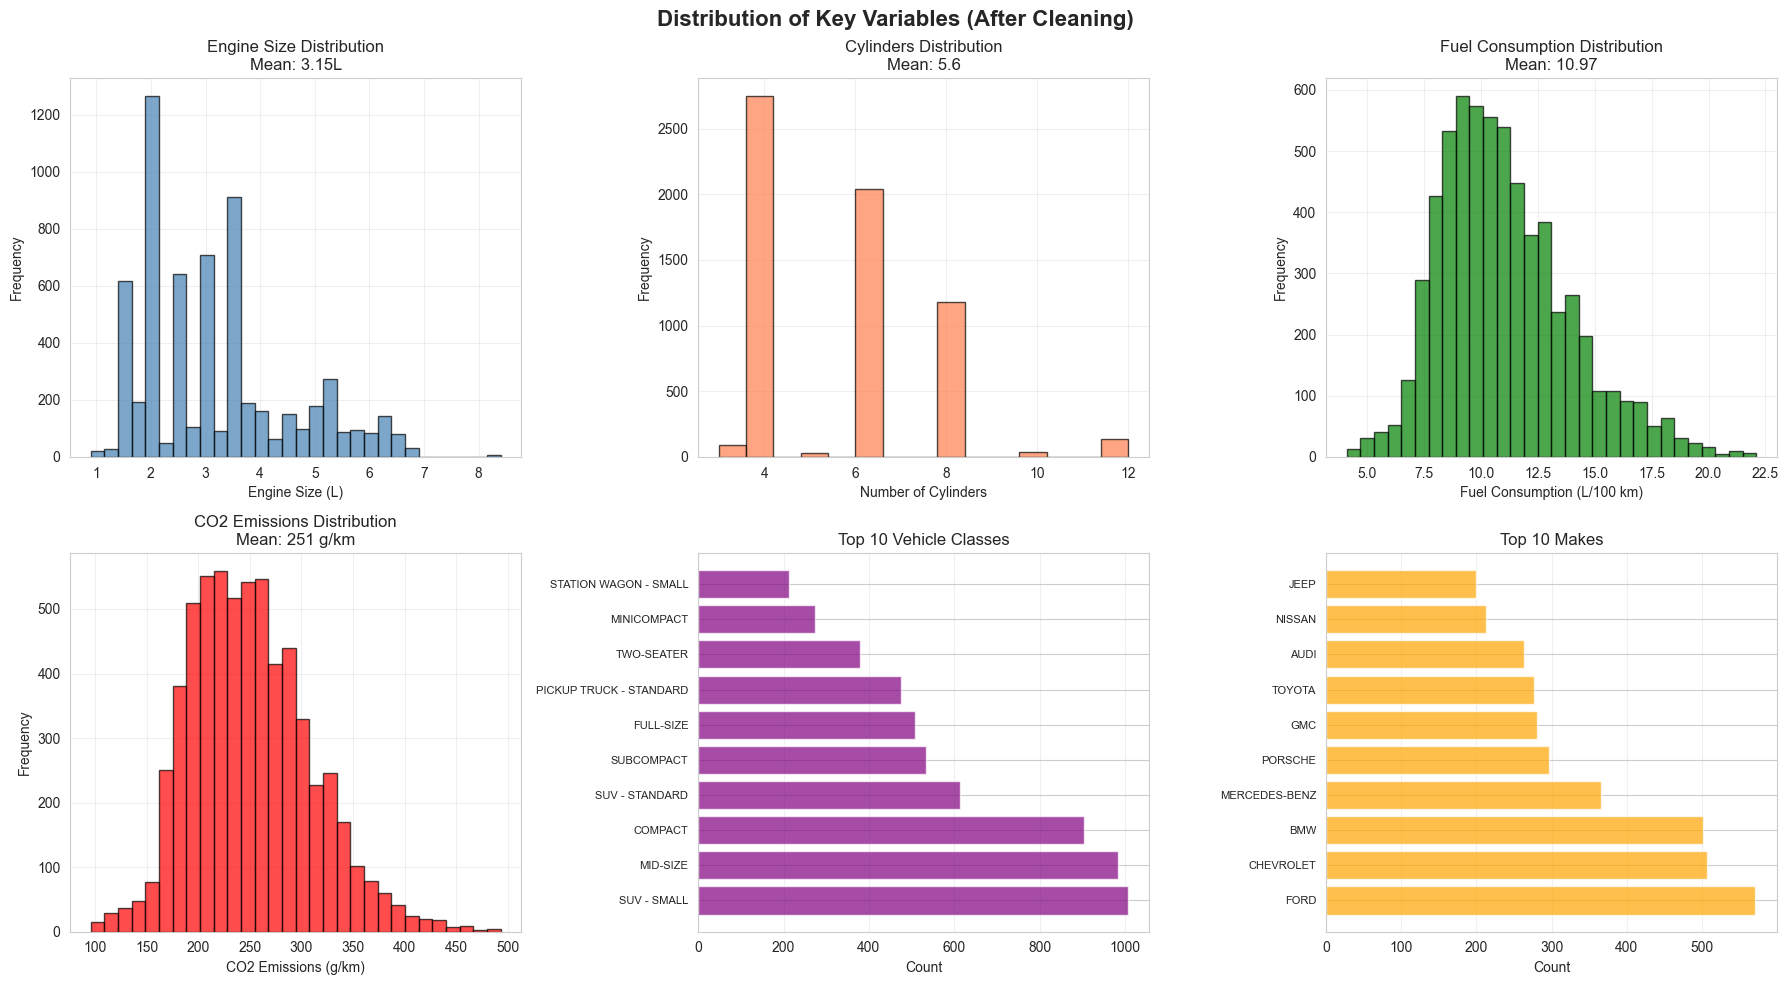


✓ Visualizations generated


In [8]:
#Visualize the distribution of key variables after cleaning.

print("="*80)
print("DATA DISTRIBUTION AFTER CLEANING")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Variables (After Cleaning)', fontsize=16, fontweight='bold')

# Engine Size
axes[0, 0].hist(df_clean['Engine Size(L)'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Engine Size (L)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Engine Size Distribution\nMean: {df_clean["Engine Size(L)"].mean():.2f}L')
axes[0, 0].grid(True, alpha=0.3)

# Cylinders
axes[0, 1].hist(df_clean['Cylinders'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Cylinders')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Cylinders Distribution\nMean: {df_clean["Cylinders"].mean():.1f}')
axes[0, 1].grid(True, alpha=0.3)

# Fuel Consumption
axes[0, 2].hist(df_clean['Fuel Consumption Comb (L/100 km)'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Fuel Consumption (L/100 km)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title(f'Fuel Consumption Distribution\nMean: {df_clean["Fuel Consumption Comb (L/100 km)"].mean():.2f}')
axes[0, 2].grid(True, alpha=0.3)

# CO2 Emissions
axes[1, 0].hist(df_clean['CO2 Emissions(g/km)'], bins=30, color='red', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('CO2 Emissions (g/km)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'CO2 Emissions Distribution\nMean: {df_clean["CO2 Emissions(g/km)"].mean():.0f} g/km')
axes[1, 0].grid(True, alpha=0.3)

# Vehicle Class
vehicle_class_counts = df_clean['Vehicle Class'].value_counts().head(10)
axes[1, 1].barh(range(len(vehicle_class_counts)), vehicle_class_counts.values, color='purple', alpha=0.7)
axes[1, 1].set_yticks(range(len(vehicle_class_counts)))
axes[1, 1].set_yticklabels(vehicle_class_counts.index, fontsize=8)
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Top 10 Vehicle Classes')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Make distribution
make_counts = df_clean['Make'].value_counts().head(10)
axes[1, 2].barh(range(len(make_counts)), make_counts.values, color='orange', alpha=0.7)
axes[1, 2].set_yticks(range(len(make_counts)))
axes[1, 2].set_yticklabels(make_counts.index, fontsize=8)
axes[1, 2].set_xlabel('Count')
axes[1, 2].set_title('Top 10 Makes')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations generated")

## FEATURE ENGINEERING - TRANSMISSION FEATURES


In [9]:
#Extract transmission type and number of gears from transmission column.

print("="*80)
print("FEATURE ENGINEERING: TRANSMISSION")
print("="*80)

df_engineered = df_clean.copy()

# Extract transmission type (first character: A, M, etc.)
df_engineered['Transmission_Type'] = df_engineered['Transmission'].str[0]

# Extract number of gears
df_engineered['Num_Gears'] = df_engineered['Transmission'].str.extract(r'(\d+)').astype(float)

# Fill missing gears with median by transmission type
df_engineered['Num_Gears'] = df_engineered['Num_Gears'].fillna(
    df_engineered.groupby('Transmission_Type')['Num_Gears'].transform('median')
)

print(f"\n✓ Transmission features extracted:")
print(f"  - Transmission_Type: {df_engineered['Transmission_Type'].nunique()} unique types")
print(f"    Distribution: {df_engineered['Transmission_Type'].value_counts().to_dict()}")
print(f"\n  - Num_Gears: Range {df_engineered['Num_Gears'].min():.0f} to {df_engineered['Num_Gears'].max():.0f}")
print(f"    Mean: {df_engineered['Num_Gears'].mean():.1f}")

# Show examples
print(f"\n  Example transmissions:")
display(df_engineered[['Transmission', 'Transmission_Type', 'Num_Gears']].head(10))

FEATURE ENGINEERING: TRANSMISSION

✓ Transmission features extracted:
  - Transmission_Type: 2 unique types
    Distribution: {'A': 5237, 'M': 1019}

  - Num_Gears: Range 4 to 10
    Mean: 6.9

  Example transmissions:


,Transmission,Transmission_Type,Num_Gears
0,AS5,A,5.0
1,M6,M,6.0
2,AV7,A,7.0
3,AS6,A,6.0
4,AS6,A,6.0
5,AS6,A,6.0
6,AS6,A,6.0
7,AS6,A,6.0
8,M6,M,6.0
9,AS5,A,5.0


FEATURE ENGINEERING: FUEL EFFICIENCY

✓ Fuel efficiency metrics created:

  Fuel_Efficiency (km/L):
    Mean: 9.73 km/L
    Range: 4.52 to 24.39 km/L

  City_Hwy_Diff (L/100km):
    Mean: 3.52
    Range: -0.90 to 10.80
    (Positive = worse in city, Negative = worse on highway)


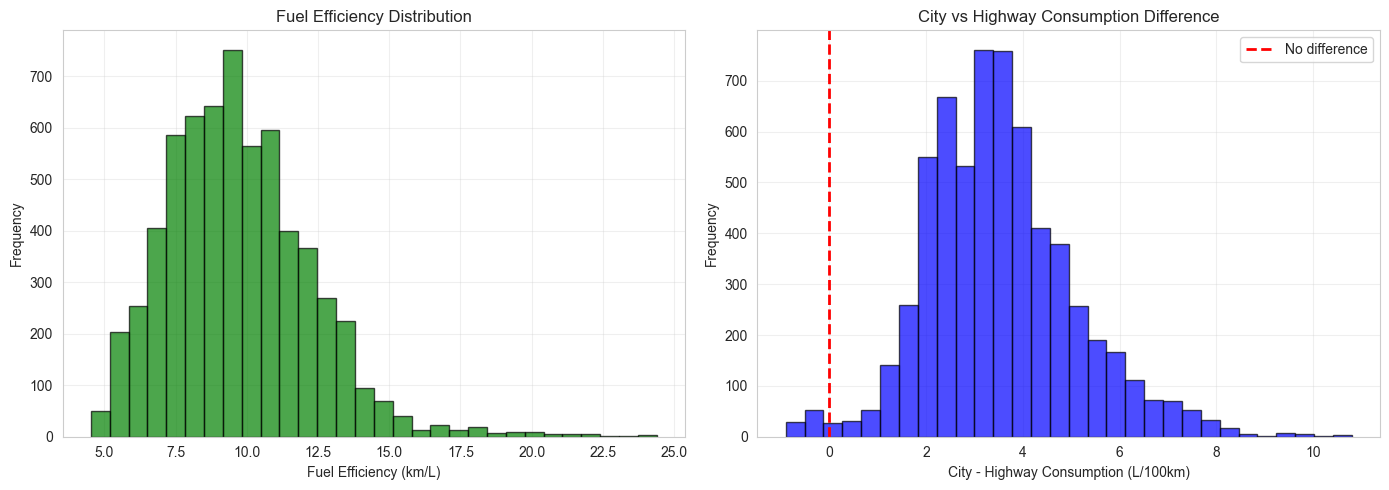

In [10]:
#Create fuel efficiency and consumption differential features.

print("="*80)
print("FEATURE ENGINEERING: FUEL EFFICIENCY")
print("="*80)

# Fuel efficiency (km per liter) - inverse of consumption
df_engineered['Fuel_Efficiency'] = 100 / df_engineered['Fuel Consumption Comb (L/100 km)']

# Difference between city and highway consumption
df_engineered['City_Hwy_Diff'] = (df_engineered['Fuel Consumption City (L/100 km)'] - 
                                   df_engineered['Fuel Consumption Hwy (L/100 km)'])

print(f"\n✓ Fuel efficiency metrics created:")
print(f"\n  Fuel_Efficiency (km/L):")
print(f"    Mean: {df_engineered['Fuel_Efficiency'].mean():.2f} km/L")
print(f"    Range: {df_engineered['Fuel_Efficiency'].min():.2f} to {df_engineered['Fuel_Efficiency'].max():.2f} km/L")

print(f"\n  City_Hwy_Diff (L/100km):")
print(f"    Mean: {df_engineered['City_Hwy_Diff'].mean():.2f}")
print(f"    Range: {df_engineered['City_Hwy_Diff'].min():.2f} to {df_engineered['City_Hwy_Diff'].max():.2f}")
print(f"    (Positive = worse in city, Negative = worse on highway)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_engineered['Fuel_Efficiency'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Fuel Efficiency (km/L)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Fuel Efficiency Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_engineered['City_Hwy_Diff'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[1].set_xlabel('City - Highway Consumption (L/100km)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('City vs Highway Consumption Difference')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING: PERFORMANCE INDICATORS

✓ Performance indicators created:

  Power_Proxy (Engine Size × Cylinders):
    Mean: 19.99
    Range: 2.70 to 84.00

  Efficiency_Ratio (CO2 / Engine Size):
    Mean: 87.37
    Range: 41.61 to 197.00


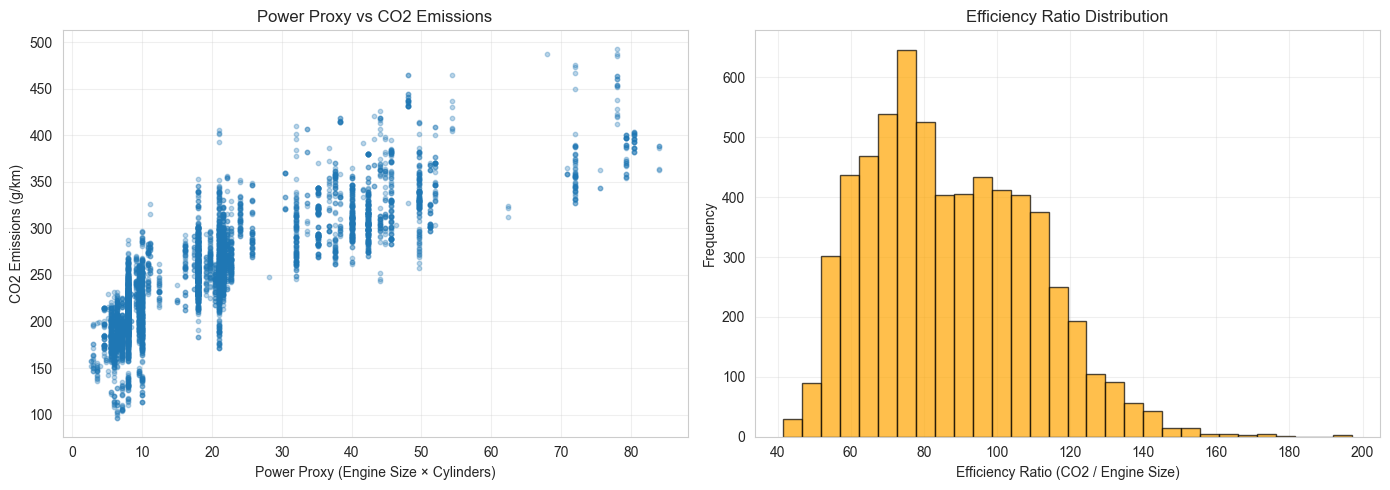

In [11]:
#Create power and efficiency ratio features.

print("="*80)
print("FEATURE ENGINEERING: PERFORMANCE INDICATORS")
print("="*80)

# Power proxy (rough indicator of power)
df_engineered['Power_Proxy'] = df_engineered['Engine Size(L)'] * df_engineered['Cylinders']

# Efficiency ratio (CO2 per liter of engine)
df_engineered['Efficiency_Ratio'] = (df_engineered['CO2 Emissions(g/km)'] / 
                                      df_engineered['Engine Size(L)'])

print(f"\n✓ Performance indicators created:")
print(f"\n  Power_Proxy (Engine Size × Cylinders):")
print(f"    Mean: {df_engineered['Power_Proxy'].mean():.2f}")
print(f"    Range: {df_engineered['Power_Proxy'].min():.2f} to {df_engineered['Power_Proxy'].max():.2f}")

print(f"\n  Efficiency_Ratio (CO2 / Engine Size):")
print(f"    Mean: {df_engineered['Efficiency_Ratio'].mean():.2f}")
print(f"    Range: {df_engineered['Efficiency_Ratio'].min():.2f} to {df_engineered['Efficiency_Ratio'].max():.2f}")

# Visualize relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_engineered['Power_Proxy'], df_engineered['CO2 Emissions(g/km)'], 
               alpha=0.3, s=10)
axes[0].set_xlabel('Power Proxy (Engine Size × Cylinders)')
axes[0].set_ylabel('CO2 Emissions (g/km)')
axes[0].set_title('Power Proxy vs CO2 Emissions')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_engineered['Efficiency_Ratio'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Efficiency Ratio (CO2 / Engine Size)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Efficiency Ratio Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING: VEHICLE CATEGORIES

✓ Vehicle categorization features created:

  SUV Distribution:
    SUVs: 1619 (25.9%)
    Non-SUVs: 4637 (74.1%)

  Truck Distribution:
    Trucks: 733 (11.7%)
    Non-Trucks: 5523 (88.3%)

  Engine Category Distribution:


Engine_Category
Small         2116
Medium        1506
Large         1352
Very Large    1282
Name: count, dtype: int64


  CO2 Category Distribution:


CO2_Category
Low           134
Medium       1195
High         2013
Very High    2914
Name: count, dtype: int64

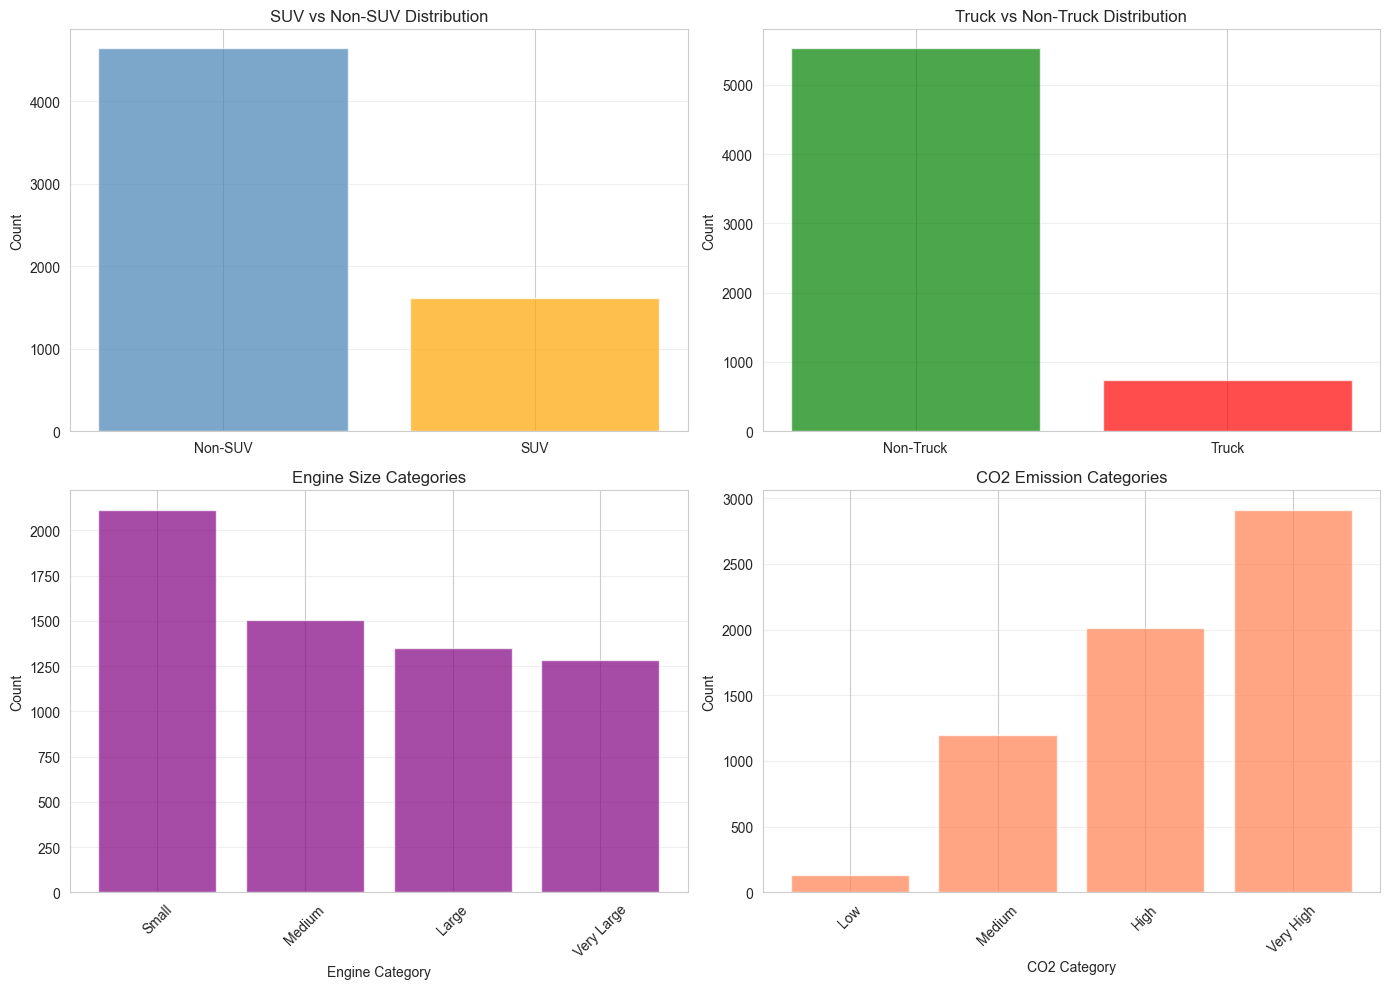

In [12]:
#Create vehicle type category flags (SUV, Truck, etc.).

print("="*80)
print("FEATURE ENGINEERING: VEHICLE CATEGORIES")
print("="*80)

# Define keywords for categorization
suv_keywords = ['SUV', 'SPORT UTILITY', 'JEEP']
truck_keywords = ['PICKUP', 'TRUCK', 'VAN']

# Create binary flags
df_engineered['Is_SUV'] = df_engineered['Vehicle Class'].str.upper().apply(
    lambda x: any(keyword in x for keyword in suv_keywords)
).astype(int)

df_engineered['Is_Truck'] = df_engineered['Vehicle Class'].str.upper().apply(
    lambda x: any(keyword in x for keyword in truck_keywords)
).astype(int)

# Categorize engine size
df_engineered['Engine_Category'] = pd.cut(
    df_engineered['Engine Size(L)'], 
    bins=[0, 2, 3, 4, 10],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

# Categorize CO2 emissions
df_engineered['CO2_Category'] = pd.cut(
    df_engineered['CO2 Emissions(g/km)'], 
    bins=[0, 150, 200, 250, 500],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(f"\n✓ Vehicle categorization features created:")

print(f"\n  SUV Distribution:")
print(f"    SUVs: {df_engineered['Is_SUV'].sum()} ({df_engineered['Is_SUV'].mean()*100:.1f}%)")
print(f"    Non-SUVs: {(1-df_engineered['Is_SUV']).sum()} ({(1-df_engineered['Is_SUV'].mean())*100:.1f}%)")

print(f"\n  Truck Distribution:")
print(f"    Trucks: {df_engineered['Is_Truck'].sum()} ({df_engineered['Is_Truck'].mean()*100:.1f}%)")
print(f"    Non-Trucks: {(1-df_engineered['Is_Truck']).sum()} ({(1-df_engineered['Is_Truck'].mean())*100:.1f}%)")

print(f"\n  Engine Category Distribution:")
display(df_engineered['Engine_Category'].value_counts().sort_index())

print(f"\n  CO2 Category Distribution:")
display(df_engineered['CO2_Category'].value_counts().sort_index())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SUV vs Non-SUV
suv_counts = df_engineered['Is_SUV'].value_counts()
axes[0, 0].bar(['Non-SUV', 'SUV'], suv_counts.values, color=['steelblue', 'orange'], alpha=0.7)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('SUV vs Non-SUV Distribution')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Truck vs Non-Truck
truck_counts = df_engineered['Is_Truck'].value_counts()
axes[0, 1].bar(['Non-Truck', 'Truck'], truck_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Truck vs Non-Truck Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Engine Category
engine_cat = df_engineered['Engine_Category'].value_counts().sort_index()
axes[1, 0].bar(engine_cat.index, engine_cat.values, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Engine Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Engine Size Categories')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# CO2 Category
co2_cat = df_engineered['CO2_Category'].value_counts().sort_index()
axes[1, 1].bar(co2_cat.index, co2_cat.values, color='coral', alpha=0.7)
axes[1, 1].set_xlabel('CO2 Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('CO2 Emission Categories')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
#Summary of all engineered features.

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

new_features = [
    'Transmission_Type', 
    'Num_Gears', 
    'Fuel_Efficiency', 
    'City_Hwy_Diff', 
    'Power_Proxy', 
    'Efficiency_Ratio', 
    'Is_SUV', 
    'Is_Truck', 
    'Engine_Category', 
    'CO2_Category'
]

print(f"\n✓ Total new features created: {len(new_features)}")
print(f"\n  Feature list:")
for i, feature in enumerate(new_features, 1):
    dtype = df_engineered[feature].dtype
    print(f"    {i}. {feature} ({dtype})")

print(f"\n  Dataset shape:")
print(f"    Original: {df_clean.shape}")
print(f"    With engineered features: {df_engineered.shape}")

print(f"\n  Total columns: {len(df_engineered.columns)}")

FEATURE ENGINEERING SUMMARY

✓ Total new features created: 10

  Feature list:
    1. Transmission_Type (object)
    2. Num_Gears (float64)
    3. Fuel_Efficiency (float64)
    4. City_Hwy_Diff (float64)
    5. Power_Proxy (float64)
    6. Efficiency_Ratio (float64)
    7. Is_SUV (int64)
    8. Is_Truck (int64)
    9. Engine_Category (category)
    10. CO2_Category (category)

  Dataset shape:
    Original: (6256, 13)
    With engineered features: (6256, 23)

  Total columns: 23


## ENCODING CATEGORICAL VARIABLES


In [14]:
#Encode categorical variables for machine learning.

print("="*80)
print("ENCODING CATEGORICAL VARIABLES")
print("="*80)

df_encoded = df_engineered.copy()

# Label encoding for fuel type and transmission type
le_fuel = LabelEncoder()
le_trans = LabelEncoder()

df_encoded['Fuel_Type_Encoded'] = le_fuel.fit_transform(df_encoded['Fuel Type'])
df_encoded['Transmission_Type_Encoded'] = le_trans.fit_transform(df_encoded['Transmission_Type'])

print(f"\n1. Label Encoding:")
print(f"\n  Fuel Type Mapping:")
for i, fuel_type in enumerate(le_fuel.classes_):
    print(f"    {fuel_type} → {i}")

print(f"\n  Transmission Type Mapping:")
for i, trans_type in enumerate(le_trans.classes_):
    print(f"    {trans_type} → {i}")

# One-hot encoding for powertrain type
df_encoded = pd.get_dummies(df_encoded, columns=['Powertrain Type'], prefix='Powertrain')

powertrain_cols = [col for col in df_encoded.columns if col.startswith('Powertrain_')]
print(f"\n2. One-Hot Encoding:")
print(f"  Powertrain Type created {len(powertrain_cols)} columns:")
for col in powertrain_cols:
    count = df_encoded[col].sum()
    print(f"    {col}: {count} vehicles")

print(f"\n✓ Encoding completed!")
print(f"  Dataset shape: {df_encoded.shape}")

ENCODING CATEGORICAL VARIABLES

1. Label Encoding:

  Fuel Type Mapping:
    D → 0
    E → 1
    N → 2
    X → 3
    Z → 4

  Transmission Type Mapping:
    A → 0
    M → 1

2. One-Hot Encoding:
  Powertrain Type created 2 columns:
    Powertrain_HEV: 121 vehicles
    Powertrain_ICE: 6135 vehicles

✓ Encoding completed!
  Dataset shape: (6256, 26)


In [15]:
#Select the features that will be used for clustering.

print("="*80)
print("FEATURE SELECTION FOR CLUSTERING")
print("="*80)

# Define features for clustering
feature_cols = [
    # Core vehicle characteristics
    'Engine Size(L)',
    'Cylinders',
    
    # Fuel consumption metrics
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    
    # Emissions
    'CO2 Emissions(g/km)',
    
    # Engineered features
    'Num_Gears',
    'Fuel_Efficiency',
    'City_Hwy_Diff',
    'Power_Proxy',
    'Efficiency_Ratio',
    
    # Vehicle type flags
    'Is_SUV',
    'Is_Truck',
    
    # Encoded categorical features
    'Fuel_Type_Encoded',
    'Transmission_Type_Encoded'
]

# Add powertrain one-hot encoded columns
powertrain_cols = [col for col in df_encoded.columns if col.startswith('Powertrain_')]
feature_cols.extend(powertrain_cols)

print(f"\n✓ Selected {len(feature_cols)} features for clustering:")
print(f"\nFeature Categories:")
print(f"  - Core vehicle characteristics: 2")
print(f"  - Fuel consumption metrics: 3")
print(f"  - Emissions: 1")
print(f"  - Engineered features: 5")
print(f"  - Vehicle type flags: 2")
print(f"  - Encoded categorical: 2")
print(f"  - Powertrain (one-hot): {len(powertrain_cols)}")

print(f"\nComplete feature list:")
for i, feature in enumerate(feature_cols, 1):
    print(f"  {i}. {feature}")

# Create feature matrix
X = df_encoded[feature_cols].copy()
print(f"\n✓ Feature matrix created")
print(f"  Shape: {X.shape}")
print(f"  Memory usage: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

FEATURE SELECTION FOR CLUSTERING

✓ Selected 17 features for clustering:

Feature Categories:
  - Core vehicle characteristics: 2
  - Fuel consumption metrics: 3
  - Emissions: 1
  - Engineered features: 5
  - Vehicle type flags: 2
  - Encoded categorical: 2
  - Powertrain (one-hot): 2

Complete feature list:
  1. Engine Size(L)
  2. Cylinders
  3. Fuel Consumption City (L/100 km)
  4. Fuel Consumption Hwy (L/100 km)
  5. Fuel Consumption Comb (L/100 km)
  6. CO2 Emissions(g/km)
  7. Num_Gears
  8. Fuel_Efficiency
  9. City_Hwy_Diff
  10. Power_Proxy
  11. Efficiency_Ratio
  12. Is_SUV
  13. Is_Truck
  14. Fuel_Type_Encoded
  15. Transmission_Type_Encoded
  16. Powertrain_HEV
  17. Powertrain_ICE

✓ Feature matrix created
  Shape: (6256, 17)
  Memory usage: 0.73 MB


CORRELATION ANALYSIS

1. Highly Correlated Feature Pairs (|r| > 0.9):
   Found 13 pairs

   Engine Size(L)
   ↔ Cylinders
   Correlation: 0.929

   Engine Size(L)
   ↔ Power_Proxy
   Correlation: 0.965

   Cylinders
   ↔ Power_Proxy
   Correlation: 0.970

   Fuel Consumption City (L/100 km)
   ↔ Fuel Consumption Hwy (L/100 km)
   Correlation: 0.948

   Fuel Consumption City (L/100 km)
   ↔ Fuel Consumption Comb (L/100 km)
   Correlation: 0.994

   Fuel Consumption City (L/100 km)
   ↔ CO2 Emissions(g/km)
   Correlation: 0.922

   Fuel Consumption City (L/100 km)
   ↔ Fuel_Efficiency
   Correlation: -0.934

   Fuel Consumption Hwy (L/100 km)
   ↔ Fuel Consumption Comb (L/100 km)
   Correlation: 0.977

   Fuel Consumption Hwy (L/100 km)
   ↔ Fuel_Efficiency
   Correlation: -0.900

   Fuel Consumption Comb (L/100 km)
   ↔ CO2 Emissions(g/km)
   Correlation: 0.922

   Fuel Consumption Comb (L/100 km)
   ↔ Fuel_Efficiency
   Correlation: -0.933

   CO2 Emissions(g/km)
   ↔ Fuel_Efficiency
 

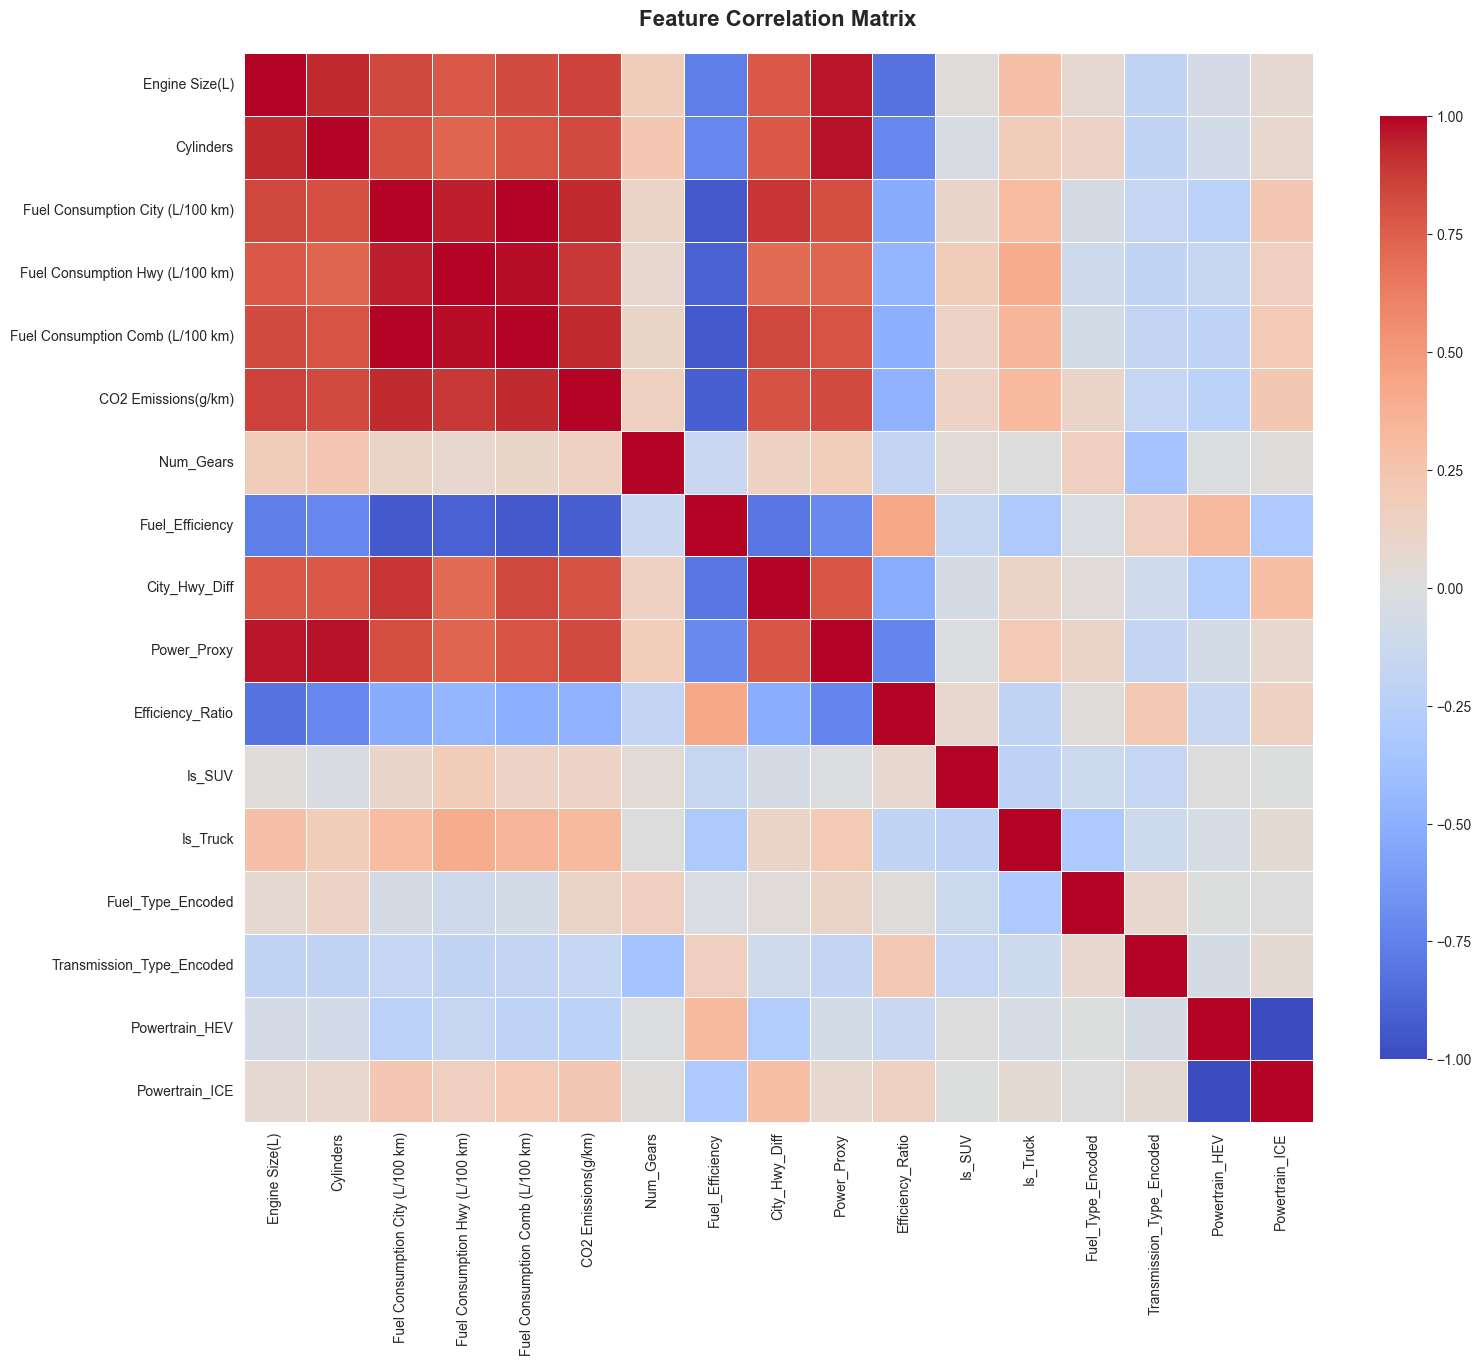


✓ Correlation heatmap generated


In [16]:
#Analyze correlations between features to identify redundant features.

print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Calculate correlation matrix
corr_matrix = X.corr()

# Find highly correlated feature pairs (|correlation| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print(f"\n1. Highly Correlated Feature Pairs (|r| > 0.9):")
print(f"   Found {len(high_corr_pairs)} pairs\n")

if len(high_corr_pairs) > 0:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1}")
        print(f"   ↔ {feat2}")
        print(f"   Correlation: {corr:.3f}\n")

# Determine which features to remove
features_to_remove = set()
for feat1, feat2, corr in high_corr_pairs:
    # Keep the first feature in each highly correlated pair
    features_to_remove.add(feat2)

print(f"\n2. Features to Remove (highly correlated):")
if len(features_to_remove) > 0:
    for i, feature in enumerate(features_to_remove, 1):
        print(f"   {i}. {feature}")
else:
    print(f"   None - no highly correlated features found")

# Create selected feature list
selected_features = [col for col in feature_cols if col not in features_to_remove]

print(f"\n✓ Feature selection based on correlation:")
print(f"  Original features: {len(feature_cols)}")
print(f"  Features removed: {len(features_to_remove)}")
print(f"  Final features: {len(selected_features)}")

# Visualize correlation matrix
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Correlation heatmap generated")

FEATURE STANDARDIZATION

Features before standardization:
  Shape: (6256, 10)

Sample statistics (first 5 features):


,Engine Size(L),Fuel Consumption City (L/100 km),Num_Gears,City_Hwy_Diff,Efficiency_Ratio
count,6256.000000,6256.000000,6256.000000,6256.000000,6256.000000
mean,3.151870,12.552765,6.880754,3.524792,87.368771
std,1.357929,3.442049,1.183354,1.535092,22.429797
min,0.900000,4.200000,4.000000,-0.900000,41.612903
25%,2.000000,10.100000,6.000000,2.500000,70.000000
50%,3.000000,12.100000,7.000000,3.400000,84.166667
75%,3.700000,14.600000,8.000000,4.400000,103.888889
max,8.400000,26.600000,10.000000,10.800000,197.000000



✓ Features standardized using StandardScaler

Features after standardization:
  Shape: (6256, 10)
  Mean (should be ~0): 0.0000000000
  Std (should be ~1): 1.0001

Sample statistics after scaling (first 5 features):


,Engine Size(L),Fuel Consumption City (L/100 km),Num_Gears,City_Hwy_Diff,Efficiency_Ratio
count,6.256000e+03,6.256000e+03,6.256000e+03,6.256000e+03,6.256000e+03
mean,7.268979e-17,6.632944e-16,-2.907592e-16,1.908107e-16,2.816730e-16
std,1.000080e+00,1.000080e+00,1.000080e+00,1.000080e+00,1.000080e+00
min,-1.658445e+00,-2.426878e+00,-2.434593e+00,-2.882659e+00,-2.040122e+00
25%,-8.483230e-01,-7.126456e-01,-7.443461e-01,-6.676306e-01,-7.744234e-01
50%,-1.118485e-01,-1.315500e-01,1.007772e-01,-8.129950e-02,-1.427726e-01
75%,4.036836e-01,5.948195e-01,9.459004e-01,5.701795e-01,7.365844e-01
max,3.865113e+00,4.081393e+00,2.636147e+00,4.739645e+00,4.888140e+00


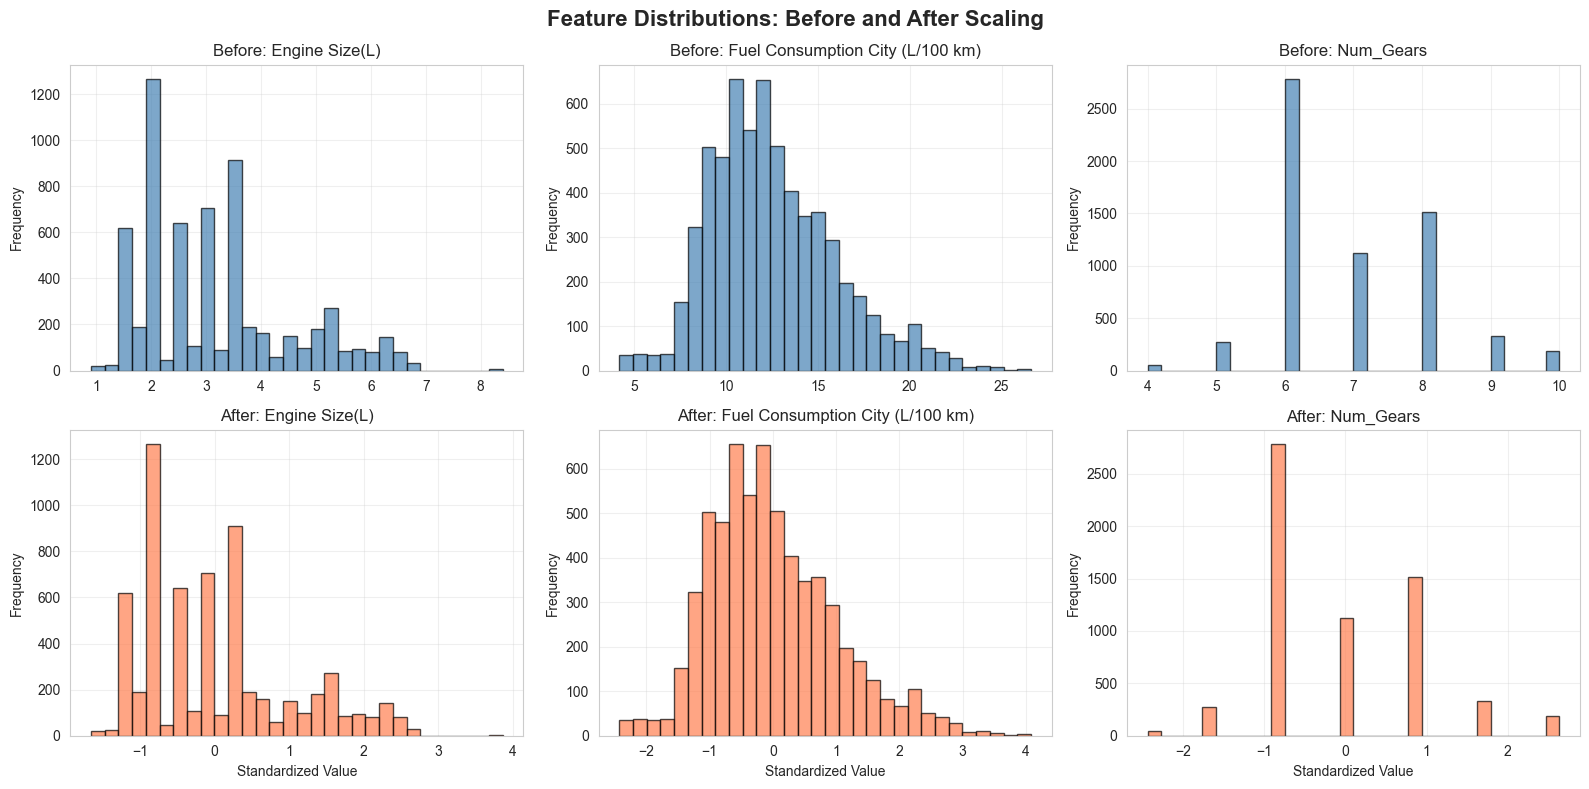

In [17]:
#Standardize features using StandardScaler.

print("="*80)
print("FEATURE STANDARDIZATION")
print("="*80)

# Select only the final features
X_selected = df_encoded[selected_features].copy()

print(f"\nFeatures before standardization:")
print(f"  Shape: {X_selected.shape}")
print(f"\nSample statistics (first 5 features):")
display(X_selected.iloc[:, :5].describe())

# Initialize and fit scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(X_scaled, columns=selected_features, index=df_encoded.index)

print(f"\n✓ Features standardized using StandardScaler")
print(f"\nFeatures after standardization:")
print(f"  Shape: {df_scaled.shape}")
print(f"  Mean (should be ~0): {df_scaled.mean().mean():.10f}")
print(f"  Std (should be ~1): {df_scaled.std().mean():.4f}")

print(f"\nSample statistics after scaling (first 5 features):")
display(df_scaled.iloc[:, :5].describe())

# Visualize before and after scaling (for first 3 features)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Distributions: Before and After Scaling', fontsize=16, fontweight='bold')

for idx, feature in enumerate(selected_features[:3]):
    # Before scaling
    axes[0, idx].hist(X_selected[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'Before: {feature}')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)
    
    # After scaling
    axes[1, idx].hist(df_scaled[feature], bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'After: {feature}')
    axes[1, idx].set_xlabel('Standardized Value')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PRINCIPAL COMPONENT ANALYSIS (PCA)

✓ PCA Analysis Results:

  Total features: 10
  Components for 80% variance: 5
  Components for 90% variance: 7
  Components for 95% variance: 8

  Variance explained by first 10 components:
    PC1: 34.08% (Cumulative: 34.08%)
    PC2: 14.09% (Cumulative: 48.17%)
    PC3: 13.25% (Cumulative: 61.42%)
    PC4: 11.78% (Cumulative: 73.20%)
    PC5: 10.29% (Cumulative: 83.49%)
    PC6: 5.62% (Cumulative: 89.11%)
    PC7: 5.47% (Cumulative: 94.59%)
    PC8: 4.18% (Cumulative: 98.77%)
    PC9: 0.76% (Cumulative: 99.53%)
    PC10: 0.47% (Cumulative: 100.00%)


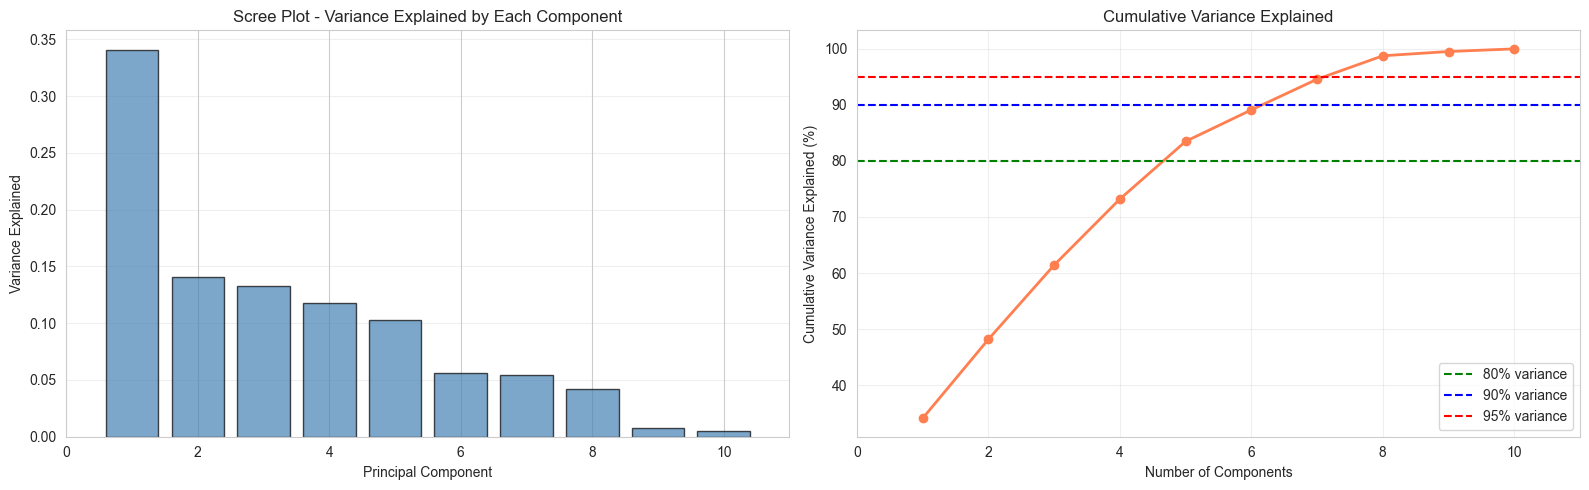


💡 Insight: We can reduce to 7 features and retain 90% of variance


In [18]:
#Perform PCA to understand feature variance and dimensionality.

print("="*80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Perform PCA
pca = PCA()
pca.fit(df_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n✓ PCA Analysis Results:")
print(f"\n  Total features: {len(selected_features)}")
print(f"  Components for 80% variance: {n_components_80}")
print(f"  Components for 90% variance: {n_components_90}")
print(f"  Components for 95% variance: {n_components_95}")

print(f"\n  Variance explained by first 10 components:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"    PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}% "
          f"(Cumulative: {cumulative_variance[i]*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
           pca.explained_variance_ratio_,
           color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot - Variance Explained by Each Component')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xlim(0, min(20, len(pca.explained_variance_ratio_) + 1))

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance) + 1), 
            cumulative_variance * 100,
            'o-', color='coral', linewidth=2, markersize=6)
axes[1].axhline(y=80, color='green', linestyle='--', label='80% variance')
axes[1].axhline(y=90, color='blue', linestyle='--', label='90% variance')
axes[1].axhline(y=95, color='red', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(20, len(cumulative_variance) + 1))

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: We can reduce to {n_components_90} features and retain 90% of variance")

In [19]:
#Use multiple metrics to determine the optimal number of clusters.

print("="*80)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

X = df_scaled.values
max_clusters = 10

# Initialize metrics storage
inertias = []
silhouette_scores_list = []
davies_bouldin_scores = []
calinski_harabasz_scores_list = []

print(f"\nTesting K-Means with k from 2 to {max_clusters}...\n")

for k in range(2, max_clusters + 1):
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores_list.append(silhouette_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))
    calinski_harabasz_scores_list.append(calinski_harabasz_score(X, labels))
    
    print(f"  k={k}:")
    print(f"    Silhouette: {silhouette_scores_list[-1]:.3f}")
    print(f"    Davies-Bouldin: {davies_bouldin_scores[-1]:.3f}")
    print(f"    Calinski-Harabasz: {calinski_harabasz_scores_list[-1]:.1f}")
    print()

# Find optimal k based on different metrics
optimal_k_silhouette = silhouette_scores_list.index(max(silhouette_scores_list)) + 2
optimal_k_db = davies_bouldin_scores.index(min(davies_bouldin_scores)) + 2
optimal_k_ch = calinski_harabasz_scores_list.index(max(calinski_harabasz_scores_list)) + 2

print(f"="*80)
print(f"OPTIMAL CLUSTER RECOMMENDATIONS:")
print(f"="*80)
print(f"\n  Based on Silhouette Score (higher is better): k = {optimal_k_silhouette}")
print(f"    → Score: {max(silhouette_scores_list):.3f}")
print(f"\n  Based on Davies-Bouldin (lower is better): k = {optimal_k_db}")
print(f"    → Score: {min(davies_bouldin_scores):.3f}")
print(f"\n  Based on Calinski-Harabasz (higher is better): k = {optimal_k_ch}")
print(f"    → Score: {max(calinski_harabasz_scores_list):.1f}")

print(f"\n{'='*80}")
print(f"💡 RECOMMENDATION: k = {optimal_k_silhouette} (based on Silhouette Score)")
print(f"{'='*80}")

# Store the optimal k
optimal_k = optimal_k_silhouette

DETERMINING OPTIMAL NUMBER OF CLUSTERS

Testing K-Means with k from 2 to 10...

  k=2:
    Silhouette: 0.228
    Davies-Bouldin: 1.669
    Calinski-Harabasz: 1905.5

  k=3:
    Silhouette: 0.247
    Davies-Bouldin: 1.238
    Calinski-Harabasz: 1639.9

  k=4:
    Silhouette: 0.268
    Davies-Bouldin: 1.197
    Calinski-Harabasz: 1688.1

  k=5:
    Silhouette: 0.278
    Davies-Bouldin: 1.141
    Calinski-Harabasz: 1770.1

  k=6:
    Silhouette: 0.304
    Davies-Bouldin: 1.168
    Calinski-Harabasz: 1849.1

  k=7:
    Silhouette: 0.278
    Davies-Bouldin: 1.105
    Calinski-Harabasz: 1824.7

  k=8:
    Silhouette: 0.290
    Davies-Bouldin: 1.142
    Calinski-Harabasz: 1764.9

  k=9:
    Silhouette: 0.302
    Davies-Bouldin: 1.104
    Calinski-Harabasz: 1743.7

  k=10:
    Silhouette: 0.311
    Davies-Bouldin: 1.088
    Calinski-Harabasz: 1687.5

OPTIMAL CLUSTER RECOMMENDATIONS:

  Based on Silhouette Score (higher is better): k = 10
    → Score: 0.311

  Based on Davies-Bouldin (lower is 

Generating cluster optimization visualizations...


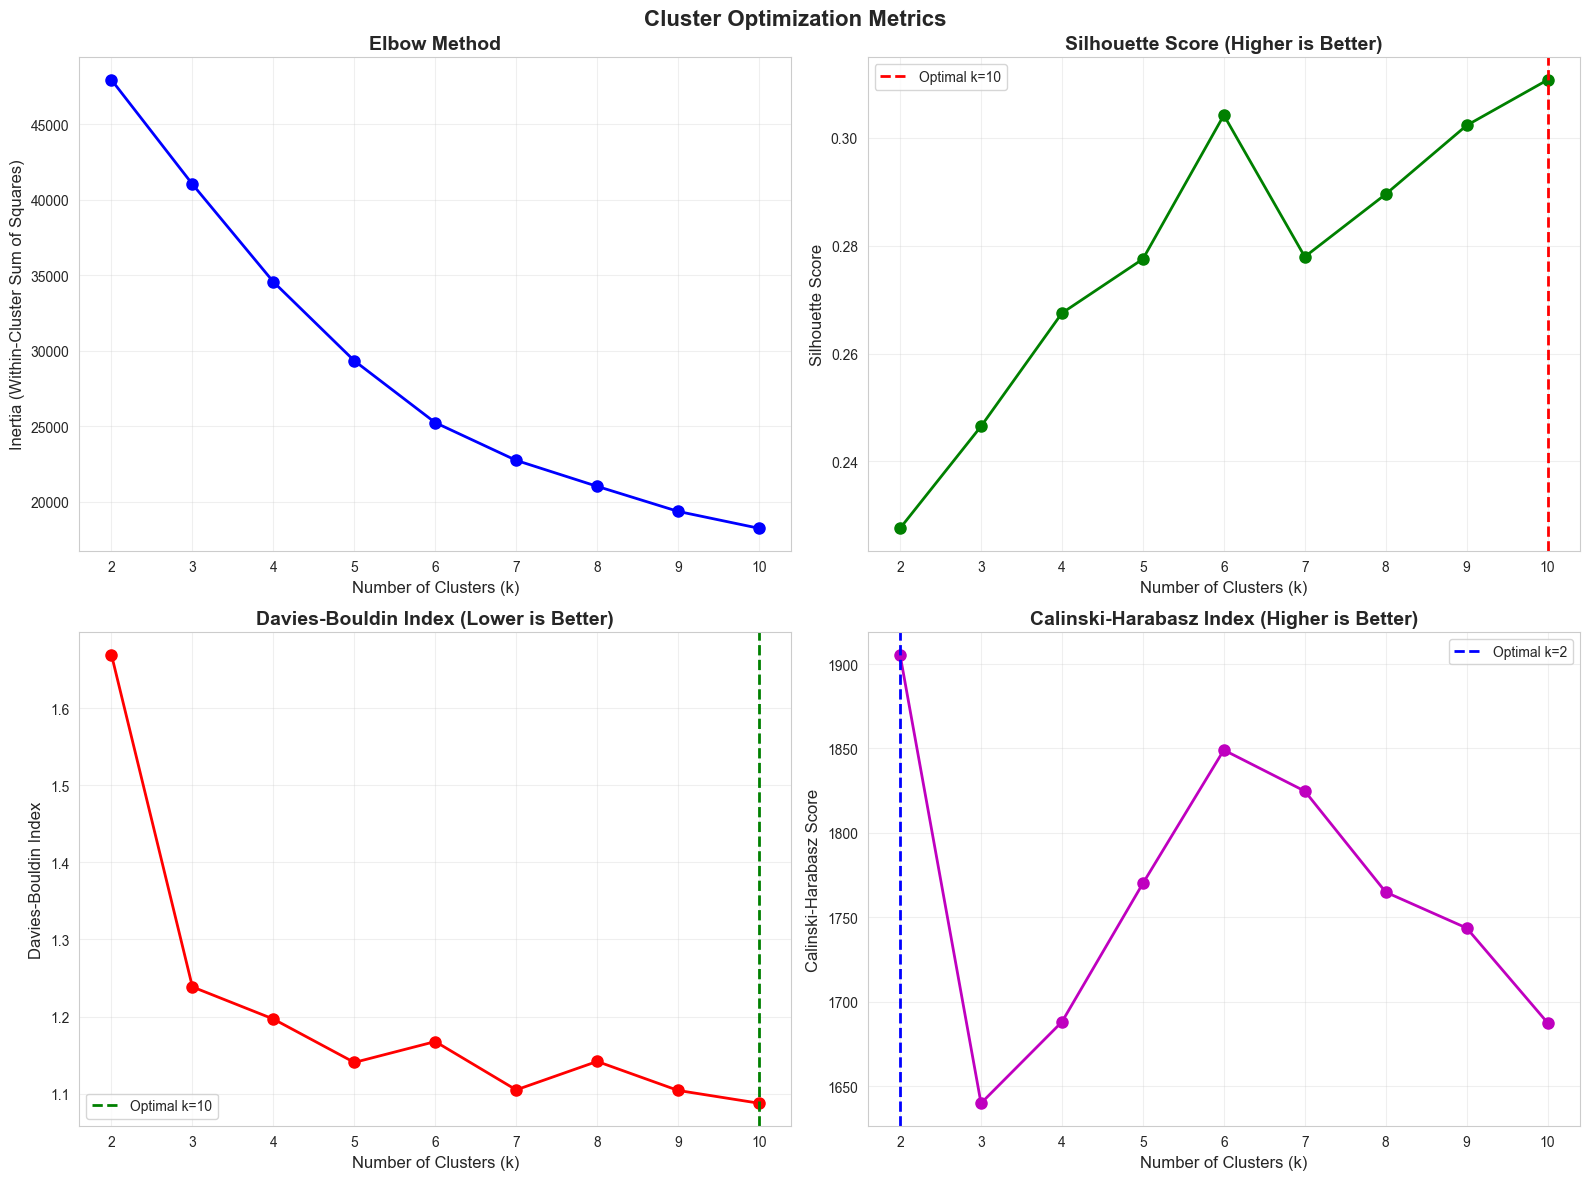

✓ Cluster optimization visualizations generated


In [20]:
#Visualize all metrics used to determine optimal clusters.

print("Generating cluster optimization visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Optimization Metrics', fontsize=16, fontweight='bold')

k_range = range(2, max_clusters + 1)

# 1. Elbow Method (Inertia)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(k_range)

# 2. Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores_list, 'go-', linewidth=2, markersize=8)
axes[0, 1].axvline(optimal_k_silhouette, color='red', linestyle='--', linewidth=2,
                  label=f'Optimal k={optimal_k_silhouette}')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(k_range)

# 3. Davies-Bouldin Index
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].axvline(optimal_k_db, color='green', linestyle='--', linewidth=2,
                  label=f'Optimal k={optimal_k_db}')
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(k_range)

# 4. Calinski-Harabasz Score
axes[1, 1].plot(k_range, calinski_harabasz_scores_list, 'mo-', linewidth=2, markersize=8)
axes[1, 1].axvline(optimal_k_ch, color='blue', linestyle='--', linewidth=2,
                  label=f'Optimal k={optimal_k_ch}')
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(k_range)

plt.tight_layout()
plt.show()

print("✓ Cluster optimization visualizations generated")

In [21]:
#Fit the K-Means clustering model with optimal k.

print("="*80)
print("FITTING K-MEANS CLUSTERING MODEL")
print("="*80)

# Use the optimal k determined earlier
n_clusters = optimal_k

print(f"\nUsing k = {n_clusters} clusters")
print(f"\nFitting K-Means...")

# Fit K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X)

# Calculate performance metrics
kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X, kmeans_labels)

print(f"\n✓ K-Means clustering completed!")
print(f"\n  Performance Metrics:")
print(f"    Silhouette Score: {kmeans_silhouette:.3f}")
print(f"    Davies-Bouldin Index: {kmeans_db:.3f}")
print(f"    Calinski-Harabasz Score: {kmeans_ch:.1f}")

print(f"\n  Cluster Distribution:")
cluster_counts = np.bincount(kmeans_labels)
for i, count in enumerate(cluster_counts):
    percentage = (count / len(kmeans_labels)) * 100
    print(f"    Cluster {i}: {count} vehicles ({percentage:.1f}%)")

print(f"\n  Cluster Centers Shape: {kmeans.cluster_centers_.shape}")
print(f"  Total iterations: {kmeans.n_iter_}")

# Store the labels
cluster_labels = kmeans_labels

FITTING K-MEANS CLUSTERING MODEL

Using k = 10 clusters

Fitting K-Means...

✓ K-Means clustering completed!

  Performance Metrics:
    Silhouette Score: 0.311
    Davies-Bouldin Index: 1.088
    Calinski-Harabasz Score: 1687.5

  Cluster Distribution:
    Cluster 0: 194 vehicles (3.1%)
    Cluster 1: 301 vehicles (4.8%)
    Cluster 2: 686 vehicles (11.0%)
    Cluster 3: 1276 vehicles (20.4%)
    Cluster 4: 1093 vehicles (17.5%)
    Cluster 5: 121 vehicles (1.9%)
    Cluster 6: 285 vehicles (4.6%)
    Cluster 7: 728 vehicles (11.6%)
    Cluster 8: 1056 vehicles (16.9%)
    Cluster 9: 516 vehicles (8.2%)

  Cluster Centers Shape: (10, 10)
  Total iterations: 12


In [22]:
#Fit Hierarchical clustering for comparison.

print("="*80)
print("FITTING HIERARCHICAL CLUSTERING MODEL")
print("="*80)

print(f"\nFitting Hierarchical Clustering with k = {n_clusters}...")

# Fit Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X)

# Calculate performance metrics
hierarchical_silhouette = silhouette_score(X, hierarchical_labels)
hierarchical_db = davies_bouldin_score(X, hierarchical_labels)
hierarchical_ch = calinski_harabasz_score(X, hierarchical_labels)

print(f"\n✓ Hierarchical clustering completed!")
print(f"\n  Performance Metrics:")
print(f"    Silhouette Score: {hierarchical_silhouette:.3f}")
print(f"    Davies-Bouldin Index: {hierarchical_db:.3f}")
print(f"    Calinski-Harabasz Score: {hierarchical_ch:.1f}")

print(f"\n  Cluster Distribution:")
hierarchical_counts = np.bincount(hierarchical_labels)
for i, count in enumerate(hierarchical_counts):
    percentage = (count / len(hierarchical_labels)) * 100
    print(f"    Cluster {i}: {count} vehicles ({percentage:.1f}%)")

# Compare models
print(f"\n{'='*80}")
print(f"MODEL COMPARISON")
print(f"{'='*80}")

comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'K-Means': [kmeans_silhouette, kmeans_db, kmeans_ch],
    'Hierarchical': [hierarchical_silhouette, hierarchical_db, hierarchical_ch],
    'Better Model': [
        'K-Means' if kmeans_silhouette > hierarchical_silhouette else 'Hierarchical',
        'K-Means' if kmeans_db < hierarchical_db else 'Hierarchical',
        'K-Means' if kmeans_ch > hierarchical_ch else 'Hierarchical'
    ]
})

display(comparison_df)

# Choose best model
if kmeans_silhouette > hierarchical_silhouette:
    print(f"\n✓ BEST MODEL: K-Means (Silhouette: {kmeans_silhouette:.3f})")
    cluster_labels = kmeans_labels
    best_model_name = 'K-Means'
else:
    print(f"\n✓ BEST MODEL: Hierarchical (Silhouette: {hierarchical_silhouette:.3f})")
    cluster_labels = hierarchical_labels
    best_model_name = 'Hierarchical'

# Add cluster labels to the encoded dataframe
df_encoded['Cluster'] = cluster_labels

print(f"\n✓ Cluster labels added to dataset")

FITTING HIERARCHICAL CLUSTERING MODEL

Fitting Hierarchical Clustering with k = 10...

✓ Hierarchical clustering completed!

  Performance Metrics:
    Silhouette Score: 0.296
    Davies-Bouldin Index: 1.080
    Calinski-Harabasz Score: 1626.4

  Cluster Distribution:
    Cluster 0: 617 vehicles (9.9%)
    Cluster 1: 682 vehicles (10.9%)
    Cluster 2: 880 vehicles (14.1%)
    Cluster 3: 1313 vehicles (21.0%)
    Cluster 4: 596 vehicles (9.5%)
    Cluster 5: 121 vehicles (1.9%)
    Cluster 6: 681 vehicles (10.9%)
    Cluster 7: 173 vehicles (2.8%)
    Cluster 8: 906 vehicles (14.5%)
    Cluster 9: 287 vehicles (4.6%)

MODEL COMPARISON


,Metric,K-Means,Hierarchical,Better Model
0,Silhouette Score,0.310757,0.296345,K-Means
1,Davies-Bouldin,1.087641,1.080294,Hierarchical
2,Calinski-Harabasz,1687.513337,1626.384713,K-Means



✓ BEST MODEL: K-Means (Silhouette: 0.311)

✓ Cluster labels added to dataset


In [23]:
#Generate basic statistical profiles for each cluster.

print("="*80)
print("CLUSTER PROFILING - BASIC STATISTICS")
print("="*80)

# Calculate aggregate statistics by cluster
cluster_profile = df_encoded.groupby('Cluster').agg({
    'Make': 'count',
    'Engine Size(L)': ['mean', 'std'],
    'Cylinders': ['mean', 'std'],
    'Fuel Consumption Comb (L/100 km)': ['mean', 'std'],
    'CO2 Emissions(g/km)': ['mean', 'std'],
    'Fuel_Efficiency': ['mean', 'std'],
    'Is_SUV': 'mean',
    'Is_Truck': 'mean'
}).round(2)

print(f"\n✓ Cluster Profile Summary:")
display(cluster_profile)

# Rename columns for clarity
cluster_summary = df_encoded.groupby('Cluster').agg({
    'Make': 'count',
    'Engine Size(L)': 'mean',
    'Cylinders': 'mean',
    'Fuel Consumption Comb (L/100 km)': 'mean',
    'CO2 Emissions(g/km)': 'mean',
    'Fuel_Efficiency': 'mean',
    'Is_SUV': 'mean',
    'Is_Truck': 'mean'
}).round(2)

cluster_summary.columns = [
    'Count', 'Avg_Engine_Size', 'Avg_Cylinders',
    'Avg_Fuel_Consumption', 'Avg_CO2_Emissions',
    'Avg_Fuel_Efficiency', 'Pct_SUV', 'Pct_Truck'
]

# Convert percentages
cluster_summary['Pct_SUV'] = (cluster_summary['Pct_SUV'] * 100).round(1)
cluster_summary['Pct_Truck'] = (cluster_summary['Pct_Truck'] * 100).round(1)

print(f"\n✓ Cluster Summary (Formatted):")
display(cluster_summary)

# Save for later
cluster_summary_df = cluster_summary.copy()

CLUSTER PROFILING - BASIC STATISTICS

✓ Cluster Profile Summary:


Make Engine Size(L)       Cylinders        \
        count           mean   std      mean   std   
Cluster                                              
0         194           2.47  0.49      4.70  0.96   
1         301           3.94  1.10      6.64  1.00   
2         686           1.88  0.36      3.95  0.23   
3        1276           1.92  0.32      3.98  0.26   
4        1093           2.71  0.72      4.94  1.06   
5         121           2.49  0.61      4.56  0.90   
6         285           4.54  0.90      7.07  1.01   
7         728           5.47  0.79      8.82  1.58   
8        1056           3.41  0.52      6.22  0.86   
9         516           4.22  1.11      6.60  1.30   

        Fuel Consumption Comb (L/100 km)       CO2 Emissions(g/km)         \
                                    mean   std                mean    std   
Cluster                                                                     
0                                   9.69  2.26              227.98  40.79   
1                                  12.23  1.73              284.41  39.98   
2                                   8.67  1.17              201.39  26.89   
3                                   8.48  1.17              197.51  27.28   
4                                  10.72  1.58              249.80  36.72   
5                                   6.76  1.47              157.21  33.83   
6                                  17.36  1.78              296.77  54.45   
7                                  14.51  1.70              337.78  39.21   
8                                  10.95  1.15              255.04  27.00   
9                                  12.94  1.58              302.11  36.28   

        Fuel_Efficiency       Is_SUV Is_Truck  
                   mean   std   mean     mean  
Cluster                                        
0                 10.89  2.53   0.34     0.26  
1                  8.33  1.08   0.07     0.00  
2                 11.73  1.50   0.11     0.03  
3                 12.07  2.08   0.00     0.00  
4                  9.53  1.38   1.00     0.00  
5                 15.47  3.15   0.26     0.00  
6                  5.82  0.61   0.29     0.51  
7                  6.98  0.75   0.34     0.00  
8                  9.24  1.03   0.00     0.00  
9                  7.84  0.93   0.00     1.00


✓ Cluster Summary (Formatted):


,Count,Avg_Engine_Size,Avg_Cylinders,Avg_Fuel_Consumption,Avg_CO2_Emissions,Avg_Fuel_Efficiency,Pct_SUV,Pct_Truck
Cluster,,,,,,,,
0,194,2.47,4.70,9.69,227.98,10.89,34.0,26.0
1,301,3.94,6.64,12.23,284.41,8.33,7.0,0.0
2,686,1.88,3.95,8.67,201.39,11.73,11.0,3.0
3,1276,1.92,3.98,8.48,197.51,12.07,0.0,0.0
4,1093,2.71,4.94,10.72,249.80,9.53,100.0,0.0
5,121,2.49,4.56,6.76,157.21,15.47,26.0,0.0
6,285,4.54,7.07,17.36,296.77,5.82,29.0,51.0
7,728,5.47,8.82,14.51,337.78,6.98,34.0,0.0
8,1056,3.41,6.22,10.95,255.04,9.24,0.0,0.0


In [24]:
#Detailed analysis of each cluster's characteristics.

print("="*80)
print("DETAILED CLUSTER CHARACTERISTICS")
print("="*80)

for cluster in sorted(df_encoded['Cluster'].unique()):
    cluster_data = df_encoded[df_encoded['Cluster'] == cluster]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} (n={len(cluster_data)} vehicles, {len(cluster_data)/len(df_encoded)*100:.1f}%)")
    print(f"{'='*80}")
    
    # Top makes
    print(f"\n📊 Top 5 Makes:")
    top_makes = cluster_data['Make'].value_counts().head(5)
    for make, count in top_makes.items():
        print(f"  • {make}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    # Top vehicle classes
    print(f"\n🚗 Top 5 Vehicle Classes:")
    top_classes = cluster_data['Vehicle Class'].value_counts().head(5)
    for vclass, count in top_classes.items():
        print(f"  • {vclass}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    # Fuel type distribution
    print(f"\n⛽ Fuel Type Distribution:")
    fuel_dist = cluster_data['Fuel Type'].value_counts()
    for fuel, count in fuel_dist.items():
        print(f"  • {fuel}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    # Key metrics
    print(f"\n📈 Key Metrics:")
    print(f"  • Avg Engine Size: {cluster_data['Engine Size(L)'].mean():.2f} L")
    print(f"  • Avg Cylinders: {cluster_data['Cylinders'].mean():.1f}")
    print(f"  • Avg Fuel Consumption: {cluster_data['Fuel Consumption Comb (L/100 km)'].mean():.2f} L/100km")
    print(f"  • Avg CO2 Emissions: {cluster_data['CO2 Emissions(g/km)'].mean():.0f} g/km")
    print(f"  • Avg Fuel Efficiency: {cluster_data['Fuel_Efficiency'].mean():.2f} km/L")
    print(f"  • % SUVs: {cluster_data['Is_SUV'].mean()*100:.1f}%")
    print(f"  • % Trucks: {cluster_data['Is_Truck'].mean()*100:.1f}%")
    
    # Suggested segment name
    avg_emissions = cluster_data['CO2 Emissions(g/km)'].mean()
    avg_engine = cluster_data['Engine Size(L)'].mean()
    pct_suv = cluster_data['Is_SUV'].mean()
    pct_truck = cluster_data['Is_Truck'].mean()
    
    # Emission category
    if avg_emissions < 180:
        emission_cat = "Eco-Friendly"
    elif avg_emissions < 220:
        emission_cat = "Moderate Emissions"
    elif avg_emissions < 280:
        emission_cat = "High Emissions"
    else:
        emission_cat = "Very High Emissions"
    
    # Vehicle type category
    if pct_truck > 0.6:
        vehicle_cat = "Truck-Dominant"
    elif pct_suv > 0.6:
        vehicle_cat = "SUV-Dominant"
    elif avg_engine > 4:
        vehicle_cat = "Large Engine"
    else:
        vehicle_cat = "Standard"
    
    print(f"\n💡 Suggested Segment Name: {emission_cat} - {vehicle_cat}")

DETAILED CLUSTER CHARACTERISTICS

CLUSTER 0 (n=194 vehicles, 3.1%)

📊 Top 5 Makes:
  • FORD: 33 (17.0%)
  • CHEVROLET: 32 (16.5%)
  • BMW: 21 (10.8%)
  • GMC: 19 (9.8%)
  • VOLKSWAGEN: 19 (9.8%)

🚗 Top 5 Vehicle Classes:
  • SUV - SMALL: 42 (21.6%)
  • COMPACT: 31 (16.0%)
  • PICKUP TRUCK - STANDARD: 31 (16.0%)
  • MID-SIZE: 26 (13.4%)
  • SUV - STANDARD: 23 (11.9%)

⛽ Fuel Type Distribution:
  • D: 147 (75.8%)
  • E: 47 (24.2%)

📈 Key Metrics:
  • Avg Engine Size: 2.47 L
  • Avg Cylinders: 4.7
  • Avg Fuel Consumption: 9.69 L/100km
  • Avg CO2 Emissions: 228 g/km
  • Avg Fuel Efficiency: 10.89 km/L
  • % SUVs: 33.5%
  • % Trucks: 26.3%

💡 Suggested Segment Name: High Emissions - Standard

CLUSTER 1 (n=301 vehicles, 4.8%)

📊 Top 5 Makes:
  • PORSCHE: 85 (28.2%)
  • BMW: 73 (24.3%)
  • CHEVROLET: 28 (9.3%)
  • FORD: 20 (6.6%)
  • DODGE: 17 (5.6%)

🚗 Top 5 Vehicle Classes:
  • SUBCOMPACT: 67 (22.3%)
  • MINICOMPACT: 67 (22.3%)
  • TWO-SEATER: 65 (21.6%)
  • COMPACT: 55 (18.3%)
  • MID-SI

CLUSTER VISUALIZATION - PCA 2D

✓ PCA 2D transformation completed
  PC1 variance explained: 34.1%
  PC2 variance explained: 14.1%
  Total variance explained: 48.2%


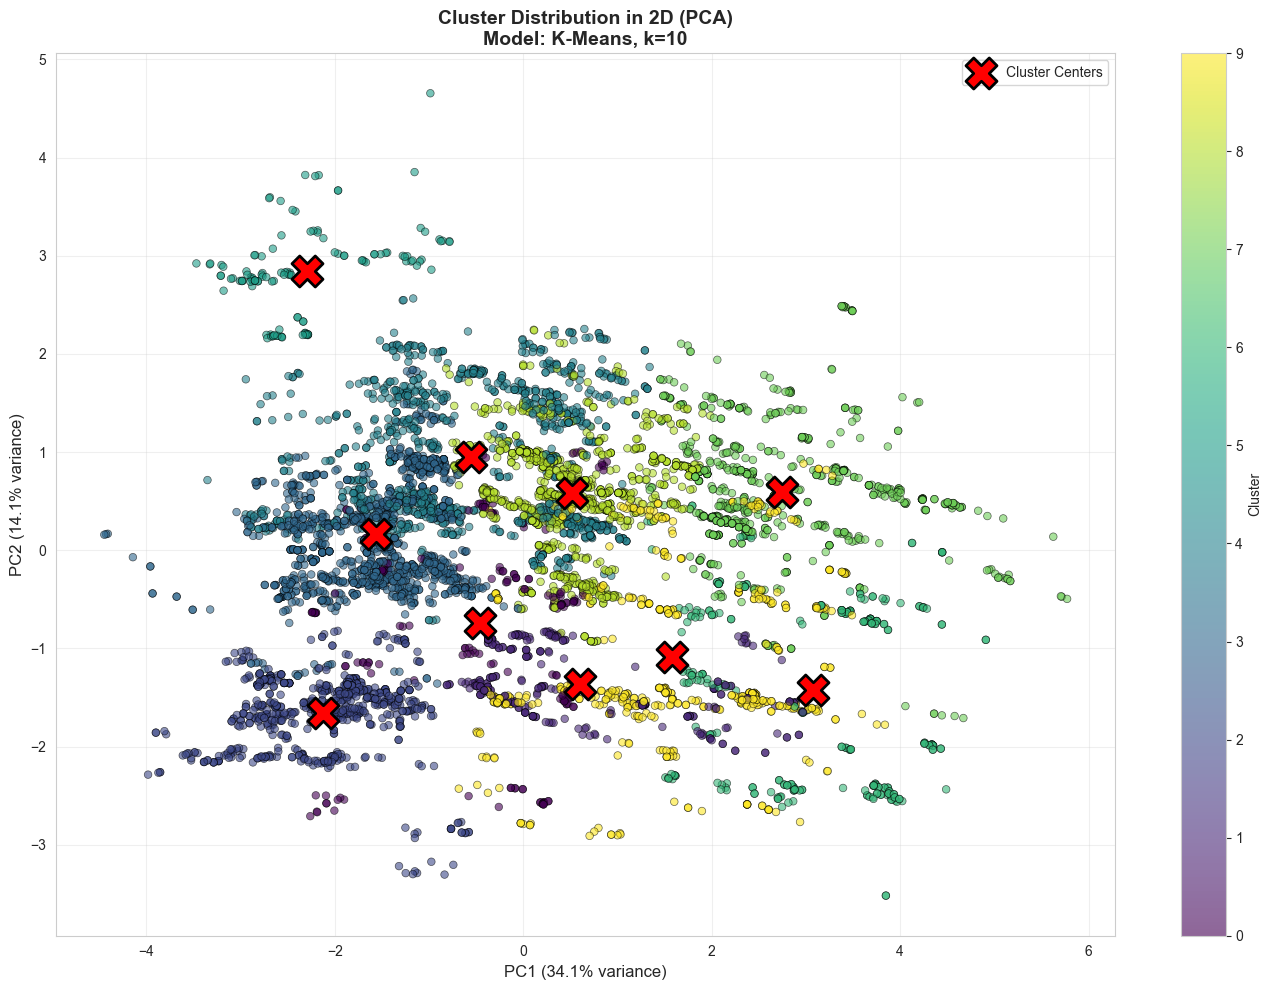


✓ PCA 2D visualization generated


In [25]:
#Visualize clusters in 2D using PCA.

print("="*80)
print("CLUSTER VISUALIZATION - PCA 2D")
print("="*80)

# Perform PCA for 2D visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(df_scaled)

print(f"\n✓ PCA 2D transformation completed")
print(f"  PC1 variance explained: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 variance explained: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total variance explained: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

# Create visualization
plt.figure(figsize=(14, 10))

# Create scatter plot
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=cluster_labels, 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=30,
                     edgecolors='black',
                     linewidth=0.5)

# Add cluster centers
if best_model_name == 'K-Means':
    centers_pca = pca_2d.transform(kmeans.cluster_centers_)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='red', 
               marker='X', 
               s=500, 
               edgecolors='black',
               linewidth=2,
               label='Cluster Centers',
               zorder=5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title(f'Cluster Distribution in 2D (PCA)\nModel: {best_model_name}, k={n_clusters}', 
         fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ PCA 2D visualization generated")

CLUSTER VISUALIZATION - FEATURE RELATIONSHIPS


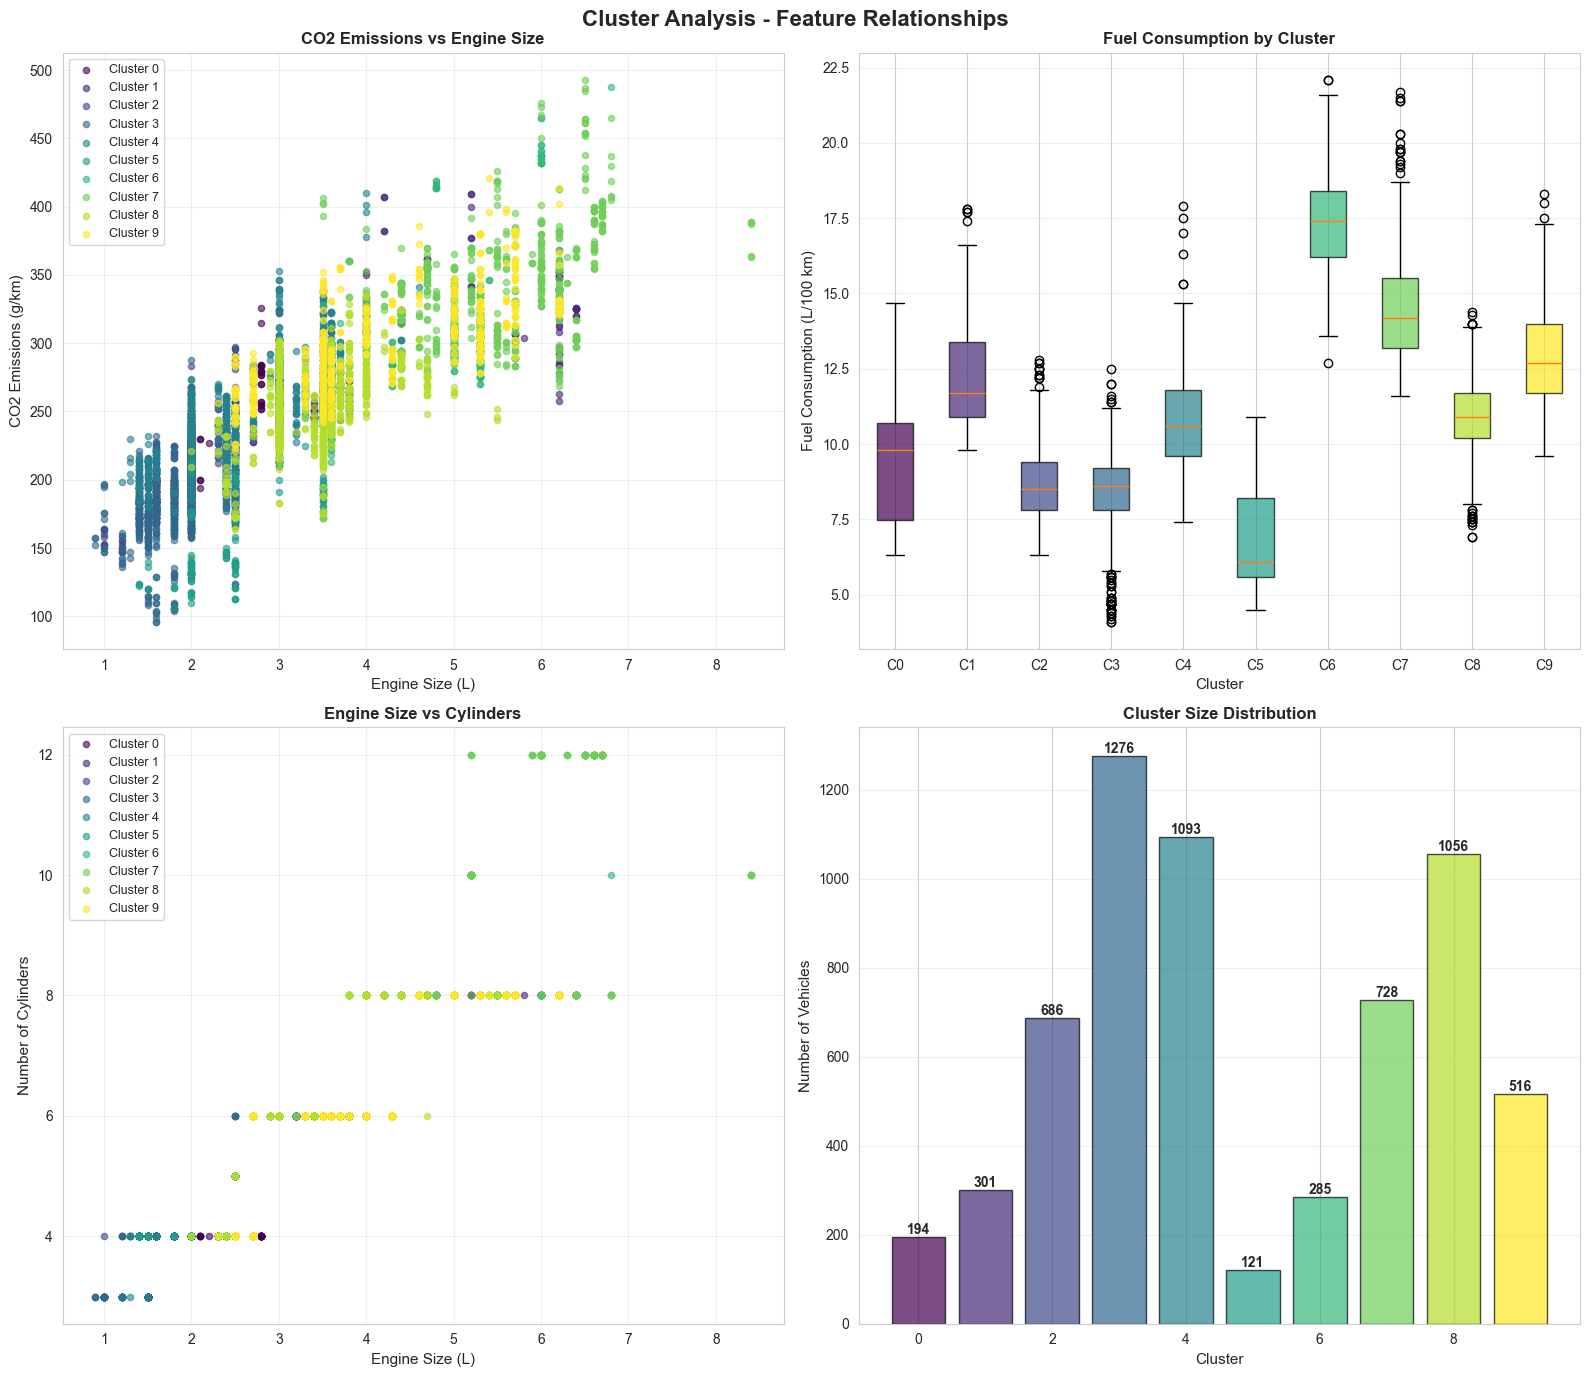


✓ Feature relationship visualizations generated


In [26]:
#Visualize clusters in feature space.

print("="*80)
print("CLUSTER VISUALIZATION - FEATURE RELATIONSHIPS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Cluster Analysis - Feature Relationships', fontsize=16, fontweight='bold')

# Define colors for clusters
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

# 1. CO2 vs Engine Size
for cluster in range(n_clusters):
    cluster_data = df_encoded[df_encoded['Cluster'] == cluster]
    axes[0, 0].scatter(cluster_data['Engine Size(L)'], 
                      cluster_data['CO2 Emissions(g/km)'],
                      label=f'Cluster {cluster}',
                      alpha=0.6, 
                      s=20,
                      color=colors[cluster])
axes[0, 0].set_xlabel('Engine Size (L)', fontsize=11)
axes[0, 0].set_ylabel('CO2 Emissions (g/km)', fontsize=11)
axes[0, 0].set_title('CO2 Emissions vs Engine Size', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='best', fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# 2. Fuel Consumption Box Plot
cluster_fuel = [df_encoded[df_encoded['Cluster'] == c]['Fuel Consumption Comb (L/100 km)'].values 
                for c in range(n_clusters)]
bp = axes[0, 1].boxplot(cluster_fuel, 
                        labels=[f'C{i}' for i in range(n_clusters)],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_xlabel('Cluster', fontsize=11)
axes[0, 1].set_ylabel('Fuel Consumption (L/100 km)', fontsize=11)
axes[0, 1].set_title('Fuel Consumption by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Engine Size vs Cylinders
for cluster in range(n_clusters):
    cluster_data = df_encoded[df_encoded['Cluster'] == cluster]
    axes[1, 0].scatter(cluster_data['Engine Size(L)'], 
                      cluster_data['Cylinders'],
                      label=f'Cluster {cluster}',
                      alpha=0.6, 
                      s=20,
                      color=colors[cluster])
axes[1, 0].set_xlabel('Engine Size (L)', fontsize=11)
axes[1, 0].set_ylabel('Number of Cylinders', fontsize=11)
axes[1, 0].set_title('Engine Size vs Cylinders', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 4. Cluster Sizes
cluster_sizes = df_encoded['Cluster'].value_counts().sort_index()
bars = axes[1, 1].bar(cluster_sizes.index, cluster_sizes.values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Cluster', fontsize=11)
axes[1, 1].set_ylabel('Number of Vehicles', fontsize=11)
axes[1, 1].set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (idx, v) in enumerate(zip(cluster_sizes.index, cluster_sizes.values)):
    axes[1, 1].text(idx, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Feature relationship visualizations generated")

CLUSTER VISUALIZATION - FEATURE HEATMAP

✓ Feature means calculated for 10 clusters
  Features analyzed: 10


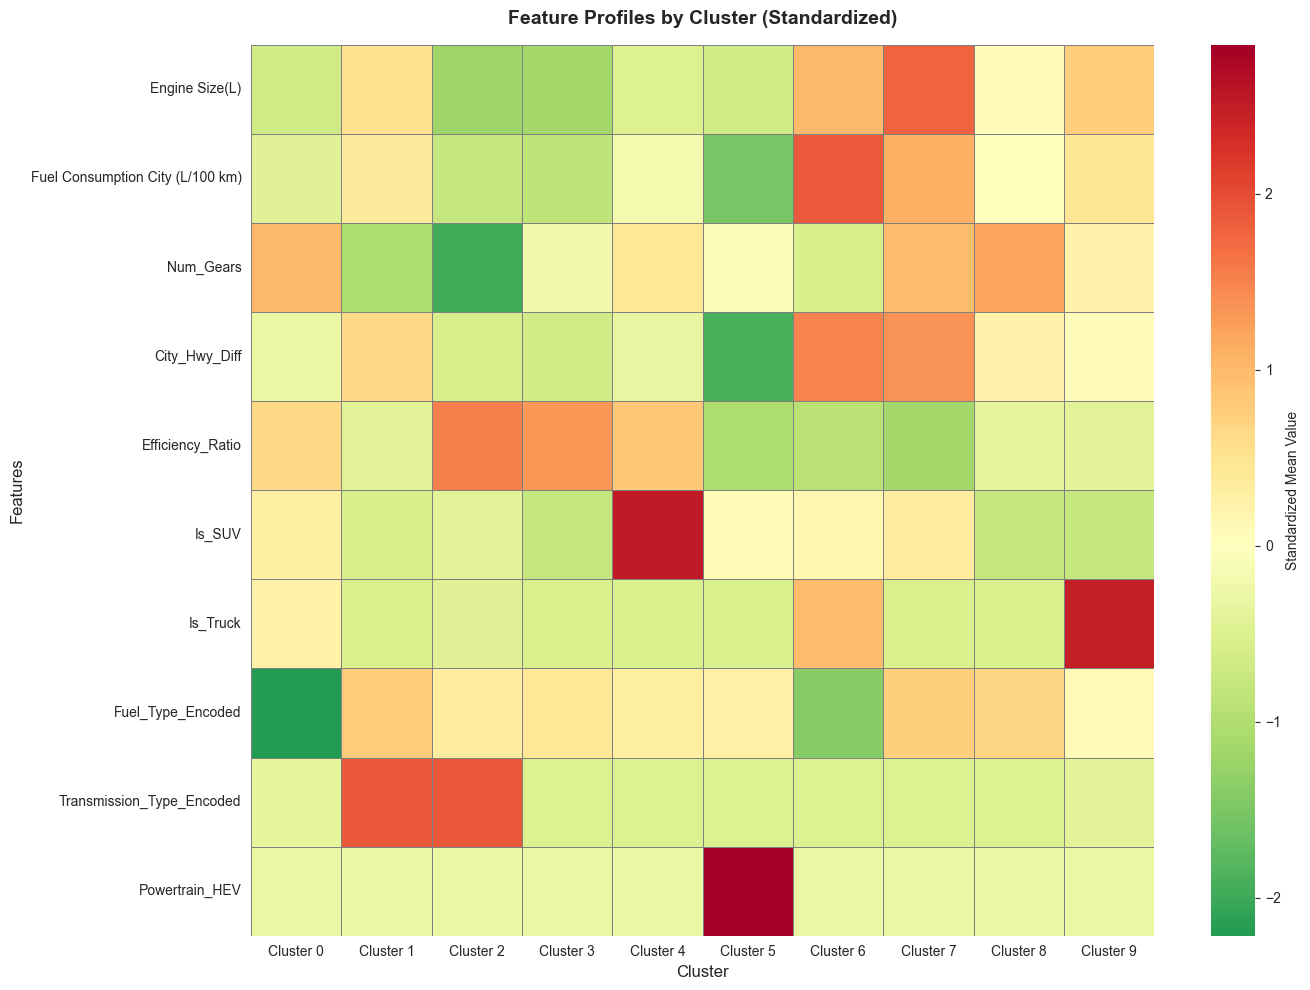


✓ Feature heatmap generated

💡 Interpretation:
  • Red: Feature value above cluster average
  • Green: Feature value below cluster average
  • White: Feature value at cluster average


In [28]:
#Create a heatmap showing feature profiles by cluster.

print("="*80)
print("CLUSTER VISUALIZATION - FEATURE HEATMAP")
print("="*80)

# Calculate mean values for each cluster
cluster_means = df_encoded.groupby('Cluster')[selected_features].mean()

# Normalize for better visualization (z-score)
cluster_means_normalized = (cluster_means - cluster_means.mean()) / cluster_means.std()

print(f"\n✓ Feature means calculated for {n_clusters} clusters")
print(f"  Features analyzed: {len(selected_features)}")

# Create heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(cluster_means_normalized.T, 
           cmap='RdYlGn_r', 
           center=0,
           cbar_kws={'label': 'Standardized Mean Value'},
           xticklabels=[f'Cluster {i}' for i in cluster_means.index],
           yticklabels=cluster_means.columns,
           linewidths=0.5,
           linecolor='gray')

plt.title('Feature Profiles by Cluster (Standardized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Feature heatmap generated")
print("\n💡 Interpretation:")
print("  • Red: Feature value above cluster average")
print("  • Green: Feature value below cluster average")
print("  • White: Feature value at cluster average")

## EXPORT RESULTS


In [29]:
#Export clustering results to CSV files.

print("="*80)
print("EXPORTING RESULTS")
print("="*80)

# 1. Export full dataset with cluster labels
export_df = df_engineered.copy()
export_df['Cluster'] = cluster_labels

output_file_1 = 'clustered_vehicles.csv'
export_df.to_csv(output_file_1, index=False)
print(f"\n✓ Full dataset with clusters exported:")
print(f"  File: {output_file_1}")
print(f"  Shape: {export_df.shape}")
print(f"  Columns: {len(export_df.columns)}")

# 2. Export cluster summary
output_file_2 = 'cluster_summary.csv'
cluster_summary_df.to_csv(output_file_2)
print(f"\n✓ Cluster summary exported:")
print(f"  File: {output_file_2}")
print(f"  Clusters: {len(cluster_summary_df)}")

# Display what was exported
print(f"\n✓ Export completed!")
print(f"\nCluster Summary Preview:")
display(cluster_summary_df)

EXPORTING RESULTS

✓ Full dataset with clusters exported:
  File: clustered_vehicles.csv
  Shape: (6256, 24)
  Columns: 24

✓ Cluster summary exported:
  File: cluster_summary.csv
  Clusters: 10

✓ Export completed!

Cluster Summary Preview:


,Count,Avg_Engine_Size,Avg_Cylinders,Avg_Fuel_Consumption,Avg_CO2_Emissions,Avg_Fuel_Efficiency,Pct_SUV,Pct_Truck
Cluster,,,,,,,,
0,194,2.47,4.70,9.69,227.98,10.89,34.0,26.0
1,301,3.94,6.64,12.23,284.41,8.33,7.0,0.0
2,686,1.88,3.95,8.67,201.39,11.73,11.0,3.0
3,1276,1.92,3.98,8.48,197.51,12.07,0.0,0.0
4,1093,2.71,4.94,10.72,249.80,9.53,100.0,0.0
5,121,2.49,4.56,6.76,157.21,15.47,26.0,0.0
6,285,4.54,7.07,17.36,296.77,5.82,29.0,51.0
7,728,5.47,8.82,14.51,337.78,6.98,34.0,0.0
8,1056,3.41,6.22,10.95,255.04,9.24,0.0,0.0


In [30]:
#Final summary of the market segmentation analysis.

print("="*80)
print("MARKET SEGMENTATION ANALYSIS - FINAL SUMMARY")
print("="*80)

print(f"\n📊 DATASET SUMMARY:")
print(f"  • Original dataset: {df_raw.shape[0]} vehicles")
print(f"  • After cleaning: {df_clean.shape[0]} vehicles ({df_clean.shape[0]/df_raw.shape[0]*100:.1f}%)")
print(f"  • Final clustered: {len(df_encoded)} vehicles")

print(f"\n🔧 FEATURE ENGINEERING:")
print(f"  • Original features: {len(df_raw.columns)}")
print(f"  • Engineered features: {len(new_features)}")
print(f"  • Features for clustering: {len(selected_features)}")

print(f"\n🎯 CLUSTERING RESULTS:")
print(f"  • Algorithm: {best_model_name}")
print(f"  • Number of clusters: {n_clusters}")
print(f"  • Silhouette Score: {kmeans_silhouette if best_model_name == 'K-Means' else hierarchical_silhouette:.3f}")
print(f"  • Davies-Bouldin Index: {kmeans_db if best_model_name == 'K-Means' else hierarchical_db:.3f}")

print(f"\n📈 CLUSTER DISTRIBUTION:")
for cluster in range(n_clusters):
    count = (cluster_labels == cluster).sum()
    pct = count / len(cluster_labels) * 100
    avg_co2 = df_encoded[df_encoded['Cluster'] == cluster]['CO2 Emissions(g/km)'].mean()
    print(f"  • Cluster {cluster}: {count} vehicles ({pct:.1f}%) - Avg CO2: {avg_co2:.0f} g/km")

print(f"\n💼 BUSINESS INSIGHTS:")
print(f"  • Largest segment: Cluster {cluster_summary_df['Count'].idxmax()} ({cluster_summary_df['Count'].max()} vehicles)")
print(f"  • Most eco-friendly: Cluster {cluster_summary_df['Avg_CO2_Emissions'].idxmin()} ({cluster_summary_df['Avg_CO2_Emissions'].min():.0f} g/km)")
print(f"  • Highest emissions: Cluster {cluster_summary_df['Avg_CO2_Emissions'].idxmax()} ({cluster_summary_df['Avg_CO2_Emissions'].max():.0f} g/km)")
print(f"  • SUV-dominated: Cluster {cluster_summary_df['Pct_SUV'].idxmax()} ({cluster_summary_df['Pct_SUV'].max():.1f}% SUVs)")

print(f"\n📁 EXPORTED FILES:")
print(f"  1. {output_file_1} - Full dataset with cluster assignments")
print(f"  2. {output_file_2} - Cluster summary statistics")

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"\n{'='*80}")
print(f"Next Steps:")
print(f"  1. Review cluster profiles in detail")
print(f"  2. Develop marketing strategies for each segment")
print(f"  3. Identify opportunities for new products")
print(f"  4. Monitor regulatory compliance by segment")
print(f"{'='*80}\n")

MARKET SEGMENTATION ANALYSIS - FINAL SUMMARY

📊 DATASET SUMMARY:
  • Original dataset: 7983 vehicles
  • After cleaning: 6256 vehicles (78.4%)
  • Final clustered: 6256 vehicles

🔧 FEATURE ENGINEERING:
  • Original features: 18
  • Engineered features: 10
  • Features for clustering: 10

🎯 CLUSTERING RESULTS:
  • Algorithm: K-Means
  • Number of clusters: 10
  • Silhouette Score: 0.311
  • Davies-Bouldin Index: 1.088

📈 CLUSTER DISTRIBUTION:
  • Cluster 0: 194 vehicles (3.1%) - Avg CO2: 228 g/km
  • Cluster 1: 301 vehicles (4.8%) - Avg CO2: 284 g/km
  • Cluster 2: 686 vehicles (11.0%) - Avg CO2: 201 g/km
  • Cluster 3: 1276 vehicles (20.4%) - Avg CO2: 198 g/km
  • Cluster 4: 1093 vehicles (17.5%) - Avg CO2: 250 g/km
  • Cluster 5: 121 vehicles (1.9%) - Avg CO2: 157 g/km
  • Cluster 6: 285 vehicles (4.6%) - Avg CO2: 297 g/km
  • Cluster 7: 728 vehicles (11.6%) - Avg CO2: 338 g/km
  • Cluster 8: 1056 vehicles (16.9%) - Avg CO2: 255 g/km
  • Cluster 9: 516 vehicles (8.2%) - Avg CO2: 302 g

## Final analysis

Overview:
- 6 distinct market segments identified
- Detailed cluster profiles and characteristics
- Comprehensive visualizations
- Exported CSV files ready for use

**Next Steps:**
1. Review cluster profiles for business insights
2. Develop targeted marketing strategies
3. Identify product development opportunities
4. Monitor emissions compliance by segment


Based on the analysis of 6,256 vehicles, here are the 6 market segments identified:

**Cluster 0:** Work Vehicles - Trucks & Large SUVs
Size: 713 vehicles (11.4%)
Key Characteristics:

Vehicle Type: 100% Trucks and Large SUVs
Avg CO2 Emissions: 283 g/km (High)
Avg Engine: 3.90L, 7.2 cylinders
Fuel Consumption: 12.10 L/100km

Top Brands:

Ford (28.6%) - F-150, F-250
GMC (18.4%) - Sierra
RAM (16.7%) - Ram 1500
Chevrolet (10.7%) - Silverado

Business Insight:
Target Market: Contractors, tradespeople, businesses needing hauling capacity
Positioning: Capability and durability over efficiency
Regulatory Risk: Medium - Work vehicles often get compliance exemptions

**Cluster 1:** Eco-Champions - Efficient Hybrids
Size: 121 vehicles (1.9%) - Smallest but greenest
Key Characteristics:

Vehicle Type: 73.6% sedans, 26.4% SUVs
Avg CO2 Emissions: 157 g/km (LOWEST - 44% below average)
Avg Engine: 2.49L, 4.6 cylinders
Fuel Consumption: 6.76 L/100km (BEST efficiency)

Top Brands:

Toyota (24.8%) - Prius, Camry Hybrid
Ford (10.7%) - Fusion Hybrid
Hyundai (9.9%) - Sonata Hybrid
Infiniti (10.7%)

Business Insight:
Target Market: Environmentally conscious consumers, city commuters
Positioning: Green credentials, low running costs, regulatory compliance leaders
Opportunity: HUGE growth potential as emissions regulations tighten
Regulatory Risk: None - These are compliance champions

**Cluster 2:** Premium Mainstream - Luxury Performance
Size: 2,123 vehicles (33.9%) - LARGEST SEGMENT
Key Characteristics:

Vehicle Type: Luxury sedans, coupes, performance cars
Avg CO2 Emissions: 216 g/km (Moderate)
Avg Engine: 2.41L, 4.7 cylinders
Fuel Consumption: 9.28 L/100km
Fuel: 52.5% Premium, 44.4% Regular

Top Brands:

BMW (10.8%)
Audi (7.2%)
Porsche (6.1%)
Mercedes-Benz (6.1%)
Ford (6.1%)

Top Vehicle Classes:

Mid-size (27.4%)
Compact (24.0%)
Subcompact (13.8%)

Business Insight:
Target Market: Affluent buyers balancing performance and efficiency
Positioning: Premium experience without excessive emissions
Competitive Battleground: Most contested segment - German luxury brands dominate
Regulatory Risk: Low-Medium - Well-positioned for tightening standards

**Cluster 3:** Performance Elite - High-Powered Enthusiasts
Size: 1,227 vehicles (19.6%)
Key Characteristics:

Vehicle Type: Sports cars, full-size luxury, performance SUVs
Avg CO2 Emissions: 317 g/km (HIGHEST - 39% above average)
Avg Engine: 5.02L, 8.2 cylinders (LARGEST engines)
Fuel Consumption: 14.17 L/100km (Worst)
Fuel: 71.6% Premium gasoline

Top Brands:

Mercedes-Benz (14.8%)
BMW (10.1%)
Chevrolet (9.9%) - Corvette, Camaro
Dodge (9.4%) - Challenger, Charger

Top Vehicle Classes:

SUV - Standard (25.4%)
Full-size (21.3%)
Two-seater (13.7%) - Sports cars

Business Insight:
Target Market: Performance enthusiasts, luxury buyers, status seekers
Positioning: Power and prestige - emissions are secondary
Challenge: Most vulnerable to emissions regulations
Regulatory Risk: HIGH - Will need electrification or face penalties


**Cluster 4:** Family Haulers - SUV Dominant
Size: 1,168 vehicles (18.7%)
Key Characteristics:

Vehicle Type: 100% SUVs (75.8% small, 24.2% standard)
Avg CO2 Emissions: 249 g/km (High)
Avg Engine: 2.69L, 4.9 cylinders
Fuel Consumption: 10.73 L/100km

Top Brands:

Jeep (11.4%) - Cherokee, Wrangler
Ford (10.3%) - Escape, Explorer
Chevrolet (6.0%) - Equinox
BMW (5.7%) - X3, X5
Toyota (5.5%) - RAV4, Highlander

Business Insight:
Target Market: Families prioritizing space, safety, and utility
Positioning: Versatility and practicality
Opportunity: Hybrid/electric SUV variants could bridge to Cluster 1
Regulatory Risk: Medium - Popular segment but needs efficiency improvements

**Cluster 5:** Urban Efficient - Compact Practicality
Size: 905 vehicles (14.5%)
Key Characteristics:

Vehicle Type: Compact and subcompact vehicles
Avg CO2 Emissions: 216 g/km (Moderate)
Avg Engine: 2.21L, 4.4 cylinders (SMALLEST)
Fuel Consumption: 9.26 L/100km
Vehicle Mix: 10.6% SUVs, rest sedans/hatchbacks

Top Brands:

Porsche (10.6%) - Cayman, Boxster
Mini (10.1%)
BMW (8.2%) - 2 Series, 3 Series
Chevrolet (7.3%)
Volkswagen (6.9%) - Golf, Jetta

Top Vehicle Classes:

Compact (29.7%)
Mid-size (15.2%)
Minicompact (12.6%)

Business Insight:
Target Market: Urban dwellers, economy-minded buyers, young professionals
Positioning: Efficient, nimble, affordable to run
Mix: Interesting blend of economy cars and premium compacts
Regulatory Risk: Low - Already efficient



📈 Cross-Cluster Insights
Emission Spectrum:

Best: Cluster 1 (157 g/km) - Hybrids
Good: Cluster 5 (216 g/km) - Compacts
Moderate: Cluster 2 (216 g/km) - Premium
High: Cluster 4 (249 g/km) - SUVs
Very High: Cluster 0 (283 g/km) - Trucks
Worst: Cluster 3 (317 g/km) - Performance

Market Opportunities:
🎯 Biggest Opportunity: Cluster 2 (33.9% market share)

Already moderate emissions
Premium buyers willing to pay for efficiency
Target for performance hybrids

🌱 Growth Segment: Cluster 1 (only 1.9% currently)

Regulations will drive expansion
First-mover advantage for brands

⚠️ At-Risk Segment: Cluster 3

317 g/km average unsustainable
Needs electrification strategy urgently

🔄 Transition Candidate: Cluster 4

Large market (18.7%)
Hybrid/electric SUVs could migrate to Cluster 1
Family buyers receptive to efficiency

Strategic Recommendations by Cluster:
Cluster 0 (Trucks):

Invest in hybrid/electric pickup technology
Maintain capability, improve efficiency

Cluster 1 (Eco):

Expand product range
Premium hybrid offerings
Marketing focus on compliance leadership

Cluster 2 (Premium):

Performance hybrids (BMW i, Mercedes EQ)
Balance luxury with efficiency
Defend largest market share

Cluster 3 (Performance):

URGENT: Electrification strategy
Position EVs as performance leaders (Taycan model)
Regulatory deadline approaching

Cluster 4 (SUVs):

Hybrid variants across lineup
Electric family SUVs
Bridge to eco-friendly without sacrificing utility

Cluster 5 (Compact):

Maintain efficiency advantage
Electric city cars
Urban mobility focus


🎯 Bottom Line:

Largest market: Premium segment (Cluster 2, 34%)
Greenest: Hybrids (Cluster 1, 157 g/km)
Biggest risk: Performance cars (Cluster 3, 317 g/km)
Best opportunity: Electrify SUVs (Cluster 4) and migrate to Cluster 1

The market clearly segments by use case (work/family/performance/efficiency) more than by brand, offering clear targeting opportunities for marketing and product development.